# L'équipement sportif des communes

Ce notebook se divise en deux parties :  
- **Partie 1** : Classification automatique des communes "bien équipées" vs "mal équipées" sur la base des caractéristiques de leurs équipements.  
**But :** Créer un modèle (RandomForest) qui apprend à **prédire** si une commune est bien équipée en infrastructures sportives ou non, en se basant sur les caractéristiques de ses équipements (type, couverture, accessibilité).

- **Partie 2** : Classification automatique des communes "bien équipées" vs "mal-équipées" sur la base de caractéristiques démographiques.  
**But :** Créer un modèle (RandomForest) qui apprend à prédire si une commune est bien équipée en infrastructures sportives ou non, en se basant cette fois-ci sur des caractéristiques non liées à ses équipements sportifs mais sur des **indicateurs socio-démographiques**.


## Partie 1 : *Classification automatique des communes "bien équipées" vs "mal équipées" sur la base des caractéristiques de leurs équipements*  
Données brutes collectées sur le site https://equipements.sports.gouv.fr/. Ce site propose la base de données Data ES, qui recense les équipements sportifs et lieux de pratiques en France. Cette base est mise à jour quotidiennement et couvre l'ensemble du territoire national.  


**Etapes :**
- Chargement et nettoyage des données
- Agrégation des données par commune (X features)
- Création de la variable cible Y
- Modélisation par RandomForest

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import ast
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
# !pip install shap
import shap

## 1. Chargement et nettoyage des données

### 1.1. Chargement des données

In [40]:
# Téléchargement manuel du fichier depuis la plateforme (bouton "Exporter" > CSV)
# Lien : https://equipements.sports.gouv.fr/explore/dataset/data-es/export/

In [41]:
# Chargement du fichier
df = pd.read_csv("data-es.csv", sep=';', low_memory=False) 
# low_memory contourne le warning indiquant que certaines colonnes ont des types mélangés pouvant ralentir le chargement ou être source de problèmes lors de calcul ultérieur
# en désactivant l’optimisation de mémoire et en laissant Pandas décider du type de données plus lentement mais plus sûrement
df.shape

(332905, 119)

In [42]:
display(df.head())

,Numéro de l'installation sportive,Nom de l'installation sportive,Adresse,Code Postal,Code INSEE (sans mise à jour),Commune (sans mise à jour),Commune INSEE,Commune Nom,Statut de la fiche d'enquête,Etat de la fiche d'enquête,...,Département Nom,Réctorat Nom,Région Code,Région Nom,Densite Niveau,Densite Catégorie,ZRR Simplifié,Catégorie,QPV,QPV à 200 mètres
0,I060570007,Collège François Rabelais,95 chemin du castel,6440.0,06057,L'Escarène,06057,L'Escarène,True,Validé,...,Alpes-Maritimes,Académie de Nice,93.0,Provence-Alpes-Côte d'Azur,5.0,Bourgs ruraux,NC - Commune non classée,structurant,NaN,NaN
1,I060580003,Complexe Saint Pons,Hameau de Saint Pons,6460.0,06058,Escragnolles,06058,Escragnolles,True,Vérifié,...,Alpes-Maritimes,Académie de Nice,93.0,Provence-Alpes-Côte d'Azur,6.0,Rural à habitat dispersé,C - Classée en ZRR,NaN,NaN,NaN
2,I060580005,Complexe sportif,Place de l'école quartier St Pons,6460.0,06058,Escragnolles,06058,Escragnolles,True,Validé,...,Alpes-Maritimes,Académie de Nice,93.0,Provence-Alpes-Côte d'Azur,6.0,Rural à habitat dispersé,C - Classée en ZRR,NaN,NaN,NaN
3,I060580007,Vallon de Beiral,NaN,6460.0,06058,Escragnolles,06058,Escragnolles,True,Validé,...,Alpes-Maritimes,Académie de Nice,93.0,Provence-Alpes-Côte d'Azur,6.0,Rural à habitat dispersé,C - Classée en ZRR,NaN,NaN,NaN
4,I060580008,Vallon de la Colle Amont,NaN,6460.0,06058,Escragnolles,06058,Escragnolles,True,Validé,...,Alpes-Maritimes,Académie de Nice,93.0,Provence-Alpes-Côte d'Azur,6.0,Rural à habitat dispersé,C - Classée en ZRR,NaN,NaN,NaN


In [43]:
# Liste complète des colonnes
# for i, col in enumerate(df.columns, 1):
    # print(f"{i:3d}. {col}")

In [44]:
# Conservation de certaines colonnes uniquement
df = df[["Numéro de l'installation sportive", "Nom de l'installation sportive", "Code Postal", "Commune INSEE", "Commune Nom", 
         "Accessibilité de l'installation en faveur des personnes en situation de handicap", "Date de l'enquête", 
         "Accessibilité de l'installation en transport en commun", "Numéro de l'équipement sportif", "Nom de l'équipement sportif", 
         "Type d'équipement sportif", "Famille d'équipement sportif", "Coordonnées", "Longitude (WGS84)", "Latitude (WGS84)",
         "Surface de l'aire d'évolution", "Surface du bassin", "Année de mise en service", 
         "Type d'utilisation", "Nature de l'équipement sportif", "Période de mise en service"]].rename(
         columns={"Numéro de l'installation sportive": "num_install",
                  "Nom de l'installation sportive": "nom_install",
                  "Code Postal": "code_postal",
                  "Commune INSEE": "code_INSEE",
                  "Commune Nom": "commune",
                  "Accessibilité de l'installation en faveur des personnes en situation de handicap": "access_handi",
                  "Date de l'enquête": "date_enquete",
                  "Accessibilité de l'installation en transport en commun": "access_transports",
                  "Numéro de l'équipement sportif": "num_equip",
                  "Nom de l'équipement sportif": "nom_equip",
                  "Type d'équipement sportif": "type_equip",
                  "Famille d'équipement sportif": "famille_equip",
                  "Coordonnées": "coordonnees",
                  "Longitude (WGS84)": "lon",
                  "Latitude (WGS84)": "lat",
                  "Surface de l'aire d'évolution": "surf_aire_evolution",
                  "Surface du bassin": "surf_bassin",
                  "Année de mise en service": "annee_mise_en_service",
                  "Type d'utilisation": "type_utilisation",
                  "Nature de l'équipement sportif": "nature_equip",
                  "Période de mise en service": "periode_mise_en_service"
                 })

### 1.2. Nettoyage des données

In [45]:
# Affichage du nombre de NA pour les colonnes concernées via une bouche qui parcourt chaque colonne
for colonne in df.columns:
    # Compter le nombre de NA
    nombre_na = df[colonne].isna().sum()
    
    # Afficher un message uniquement si la colonne contient des NA
    if nombre_na > 0:
        print(f"La colonne '{colonne}' contient {nombre_na} valeurs NA")

La colonne 'code_postal' contient 3 valeurs NA
La colonne 'code_INSEE' contient 3 valeurs NA
La colonne 'commune' contient 3 valeurs NA
La colonne 'access_handi' contient 3263 valeurs NA
La colonne 'date_enquete' contient 1075 valeurs NA
La colonne 'access_transports' contient 9617 valeurs NA
La colonne 'nom_equip' contient 1 valeurs NA
La colonne 'type_equip' contient 83 valeurs NA
La colonne 'famille_equip' contient 83 valeurs NA
La colonne 'coordonnees' contient 5257 valeurs NA
La colonne 'lon' contient 5254 valeurs NA
La colonne 'lat' contient 5247 valeurs NA
La colonne 'surf_aire_evolution' contient 51282 valeurs NA
La colonne 'surf_bassin' contient 326391 valeurs NA
La colonne 'annee_mise_en_service' contient 125508 valeurs NA
La colonne 'type_utilisation' contient 3997 valeurs NA
La colonne 'nature_equip' contient 4197 valeurs NA
La colonne 'periode_mise_en_service' contient 34132 valeurs NA


In [46]:
print(df.dtypes)

num_install                 object
nom_install                 object
code_postal                float64
code_INSEE                  object
commune                     object
access_handi                object
date_enquete                object
access_transports           object
num_equip                   object
nom_equip                   object
type_equip                  object
famille_equip               object
coordonnees                 object
lon                        float64
lat                        float64
surf_aire_evolution        float64
surf_bassin                float64
annee_mise_en_service      float64
type_utilisation            object
nature_equip                object
periode_mise_en_service     object
dtype: object


In [47]:
# Modification du type de certaines colonnes
df = df.astype({
    'num_install': 'str',
    'nom_install': 'str',
    'code_INSEE': 'str', # Non pas un entier car certaines communes ont des codes incluant des lettres (ex : 2A004 pour Ajaccio)
    'commune': 'str',
    'access_handi': 'boolean', # Accepte les NA
    'access_transports': 'boolean',
    'num_equip': 'str',
    'nom_equip': 'str',
    'type_equip': 'str',
    'famille_equip': 'str',
    'annee_mise_en_service': 'Int64',
    'nature_equip': 'str'
})

In [48]:
# Traitement spécifique pour la colonne 'code_postal' identifiée comme contenant des floats, ce qui élimine d'emblée les 0 en tête (ex : pour L'Escarène dont le code postal est 06440)
# Convertion de tous les éléments de la colonne en string, y compris les NA (pour assurer par la suite une non-mixité des types)
df['code_postal'] = df['code_postal'].fillna('').astype(str)

# Remplacement des chaînes vides (qui étaient des NA) par des NA de nouveau
df.loc[df['code_postal'] == '', 'code_postal'] = None

# Pour les valeurs non-NA, suppression de la partie décimale
df.loc[df['code_postal'].notna(), 'code_postal'] = df.loc[df['code_postal'].notna(), 'code_postal'].str.replace('.0', '', regex=False)

# Pour les valeurs non-NA, ajout des zéros en tête pour avoir 5 chiffres quand ce n'est pas le cas
df.loc[df['code_postal'].notna(), 'code_postal'] = df.loc[df['code_postal'].notna(), 'code_postal'].str.zfill(5)

In [49]:
# Traitement spécifique pour la colonne 'date_enquete' qui contient des formats mélangés (ex : '2012-06-09' et '01-01-08')
# Fonction pour convertir les différents formats de date
def convert_date(date_str):
    if pd.isna(date_str) or date_str == '':
        return np.nan
    
    try:
        # Si déjà au format yyyy-mm-dd
        return pd.to_datetime(date_str, format='%Y-%m-%d')
    except:
        try:
            # Si au format dd-mm-yy
            return pd.to_datetime(date_str, format='%d-%m-%y')
        except:
            # Si autre format, on laisse pandas essayer de deviner
            try:
                return pd.to_datetime(date_str)
            except:
                return np.nan

# Application de la fonction à la colonne
df['date_enquete'] = df['date_enquete'].apply(convert_date)

# Convertion en format yyyy-mm-dd
df['date_enquete'] = df['date_enquete'].dt.strftime('%Y-%m-%d')

# Remplacement de 'NaT' par une valeur vide
df['date_enquete'] = df['date_enquete'].replace('NaT', np.nan)

In [50]:
# Traitement à part pour la colonne type_utilisation qui doit contenir des listes
def nettoyer_type_utilisation(x):
    # Si on a une liste comme ['["Clubs sportifs', ' comités', ...]
    if isinstance(x, list):
        elements = []
        for item in x:
            # On enlève les crochets ou guillemets éventuels au début/fin
            cleaned = item.strip().strip('[]" ')
            if cleaned:  # évite les vides
                elements.append(cleaned)
        return elements
    elif isinstance(x, str):
        # Au cas où ça vient sous forme de chaîne, on split et nettoie
        return [i.strip().strip('[]" ') for i in x.split(',')]
    else:
        return x # Les NA restent automatiquement inchangés (car ni inclus dans isinstance(x, list) ni dans isinstance(x, str))

df['type_utilisation'] = df['type_utilisation'].apply(nettoyer_type_utilisation)

# Un exemple pour contrôler :
# print(df['type_utilisation'].iloc[0])

In [51]:
# print(df.dtypes) # Vérification

In [52]:
# Homogénéisation du contenu des colonnes de texte : transformation en minuscules
colonnes = ['nom_install', 'nom_equip', 'type_equip', 'famille_equip', 'type_utilisation', 'nature_equip']

for col in colonnes:
    df[col] = df[col].apply(
        lambda x: pd.NA if isinstance(x, str) and x.lower() == 'nan' else # Avant d'appliquer lower, on traite les nan qui sont actuellement des chaînes non reconnues comme des NA pour les transformer en NA
                  [i.lower() for i in x] if isinstance(x, list) else
                  x.lower() if isinstance(x, str) else
                  x
    )

In [53]:
# Traitement supplémentaire pour la colonne type_equip : est-il possible d'identifier le type d'équipement des cellules vides ?
type_na = df[df['type_equip'].isna()] # Filtrage des lignes où type_equip est NA
# display(type_na)

# Groupement par 'nom_equip' pour voir toutes les valeurs associées
grouped = type_na.groupby('nom_equip')['type_equip'].apply(list)
print(grouped)
# Pour de nombreuses cellules vides dans la colonne type_equip, le nom_equip associé est 'aire de jeux' ou 'plaine de jeux' (pour les autres, nom_equip est unique)
# Je propose donc l'ajout de deux nouveaux type_equip pour ces cellules : les type_equip 'aire de jeux' et 'plaine de jeux' :

# Remplir les valeurs NA dans type_equip selon les conditions
# Si nom_equip == 'aire de jeux', alors type_equip = 'aire de jeux'
df.loc[(df['nom_equip'] == 'aire de jeux') & (df['type_equip'].isna()), 'type_equip'] = 'aire de jeux'

# Si nom_equip == 'plaine de jeux', alors type_equip = 'plaine de jeux'
df.loc[(df['nom_equip'] == 'plaine de jeux') & (df['type_equip'].isna()), 'type_equip'] = 'plaine de jeux'

# Vérification avec un exemple : filtrage des lignes où 'type_equip' est 'aire de jeux' et affichage de 'nom_equip'
print(df[df['type_equip'] == 'aire de jeux']['nom_equip'])

nom_equip
aire de football                                                                                [<NA>]
aire de jeux                                          [<NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>]
aire de jeux de la briqueterie                                                                  [<NA>]
boucle de randonnee 5- chemin du trompe l'oeil                                                  [<NA>]
boulodrome                                                                                      [<NA>]
but de football                                                                                 [<NA>]
city stade                                                                                      [<NA>]
club de plage                                                                                   [<NA>]
club du kelenn                                                                                  [<NA>]
cour                                                           

In [54]:
# Pour info : pour bien comprendre la structure du dataframe
num_install_uniques = df['num_install'].nunique()
nom_install_uniques = df['nom_install'].nunique()
num_equip_uniques = df['num_equip'].nunique()
print("Nombre de lignes :", len(df))
print("Nombre d'installations (numéros) :", num_install_uniques, "/ Nombre d'installations (noms) :", nom_install_uniques, "/ Nombre d'équipements :", num_equip_uniques)

# De nombreuses installations (332905 - 151216 = 181689) comportent plusieurs équipements (même num_install mais num_equip différents)
# Pas de doublons dans les équipements

Nombre de lignes : 332905
Nombre d'installations (numéros) : 151216 / Nombre d'installations (noms) : 87028 / Nombre d'équipements : 332905


In [55]:
communes_uniques = df['commune'].nunique()
print("Nombre de communes étudiées :", communes_uniques)

Nombre de communes étudiées : 27004


In [56]:
display(df.head())

,num_install,nom_install,code_postal,code_INSEE,commune,access_handi,date_enquete,access_transports,num_equip,nom_equip,...,famille_equip,coordonnees,lon,lat,surf_aire_evolution,surf_bassin,annee_mise_en_service,type_utilisation,nature_equip,periode_mise_en_service
0,I060570007,collège françois rabelais,06440,06057,L'Escarène,True,2014-04-07,True,E003I060570007,gymnase,...,salle multisports,"43.841486, 7.352524",7.352524,43.841486,800.0,NaN,2013,"[clubs sportifs, comités, ligues, fédérations,...",intérieur,NaN
1,I060580003,complexe saint pons,06460,06058,Escragnolles,False,2013-04-07,False,E001I060580003,tennis,...,court de tennis,"43.72962, 6.78158",6.781580,43.729620,360.0,NaN,<NA>,"[individuel(s), famille(s), scolaires, univers...",découvert,1975-1984
2,I060580005,complexe sportif,06460,06058,Escragnolles,False,2013-04-07,False,E001I060580005,boulodrome,...,boulodrome,"43.73111111, 6.7825",6.782500,43.731111,300.0,NaN,<NA>,"[clubs sportifs, comités, ligues, fédérations]",découvert,1975-1984
3,I060580007,vallon de beiral,06460,06058,Escragnolles,False,2013-02-09,True,E001I060580007,vallon de beiral,...,divers équipements sports de nature,"43.74255, 6.76563",6.765630,43.742550,NaN,NaN,<NA>,"[clubs sportifs, comités, ligues, fédérations,...",site naturel aménagé,NaN
4,I060580008,vallon de la colle amont,06460,06058,Escragnolles,False,2013-02-09,True,E001I060580008,vallon de la colle amont,...,divers équipements sports de nature,"43.74395, 6.80557",6.805570,43.743950,NaN,NaN,<NA>,"[clubs sportifs, comités, ligues, fédérations,...",site naturel aménagé,NaN


In [57]:
# Affichage du nombre de NA pour les colonnes concernées via une bouche qui parcourt chaque colonne
for colonne in df.columns:
    # Compter le nombre de NA
    nombre_na = df[colonne].isna().sum()
    
    # Afficher un message uniquement si la colonne contient des NA
    if nombre_na > 0:
        print(f"La colonne '{colonne}' contient {nombre_na} valeurs NA")

La colonne 'code_postal' contient 3 valeurs NA
La colonne 'access_handi' contient 3263 valeurs NA
La colonne 'date_enquete' contient 1148 valeurs NA
La colonne 'access_transports' contient 9617 valeurs NA
La colonne 'nom_equip' contient 1 valeurs NA
La colonne 'type_equip' contient 40 valeurs NA
La colonne 'famille_equip' contient 83 valeurs NA
La colonne 'coordonnees' contient 5257 valeurs NA
La colonne 'lon' contient 5254 valeurs NA
La colonne 'lat' contient 5247 valeurs NA
La colonne 'surf_aire_evolution' contient 51282 valeurs NA
La colonne 'surf_bassin' contient 326391 valeurs NA
La colonne 'annee_mise_en_service' contient 125508 valeurs NA
La colonne 'type_utilisation' contient 3997 valeurs NA
La colonne 'nature_equip' contient 4197 valeurs NA
La colonne 'periode_mise_en_service' contient 34132 valeurs NA


In [58]:
# Sélection et affichage des lignes où 'coordonnees' est vide mais 'lat' et/ou 'lon' est remplie
resultat = df[(df['coordonnees'].isna()) & ((~df['lat'].isna()) | (~df['lon'].isna()))]
display(resultat)
# On dénombre une ligne pour laquelle on dispose à la fois de 'lon' et 'lat' (on pourrait donc vouloir remplir 'coordonnees') mais la longitude associée est aberrante

,num_install,nom_install,code_postal,code_INSEE,commune,access_handi,date_enquete,access_transports,num_equip,nom_equip,...,famille_equip,coordonnees,lon,lat,surf_aire_evolution,surf_bassin,annee_mise_en_service,type_utilisation,nature_equip,periode_mise_en_service
48417,I314600008,chemin piétonnier de roquettes,31120,31460,Roquettes,False,NaN,True,E001I314600008,chemin piétonnier de roquettes,...,divers équipements sports de nature,NaN,NaN,0.000000,NaN,NaN,2017,NaN,<NA>,NaN
50145,I330420003,stade de suzon,33830,33042,Belin-Béliet,False,2005-09-26,False,E001I330420003,salle des sports,...,salle multisports,NaN,NaN,44.498265,1357.0,NaN,<NA>,"[clubs sportifs, comités, ligues, fédérations,...",intérieur,1995 - 2004
146125,I591310004,complexe albert denvers,59180,59131,Cappelle-la-Grande,False,2019-05-17,False,E007I591310004,boulodrome,...,boulodrome,NaN,NaN,0.000000,50.0,NaN,2017,NaN,découvert,A partir de 2005
166335,I605890001,stade de football michel letellier,60740,60589,Saint-Maximin,True,2018-12-11,False,E003I605890001,terrain de bicross,...,equipement de cyclisme,NaN,NaN,0.000000,NaN,NaN,<NA>,"[clubs sportifs, comités, ligues, fédérations,...",découvert,A partir de 2005
166359,I605890009,etangs de peche,60740,60589,Saint-Maximin,True,2018-12-11,True,E001I605890009,etang de pêche,...,site d'activités aquatiques et nautiques,NaN,NaN,0.000000,NaN,NaN,<NA>,"[clubs sportifs, comités, ligues, fédérations]",site naturel,1975-1984
172980,I600870003,centre équestre bruno lechevalier,60300,60087,Borest,True,2018-10-25,False,E004I600870003,parcours de santé,...,parcours sportif/santé,NaN,NaN,0.000000,NaN,NaN,<NA>,"[individuel(s), famille(s), autre - associatio...",découvert,A partir de 2005
189629,I641020079,jump academy cc ametzondo,64990,64496,Saint-Pierre-d'Irube,True,2020-07-12,True,E001I641020079,trampoline park,...,salle ou terrain spécialisé,NaN,NaN,43.483260,890.0,NaN,2020,"[individuel(s), famille(s)]",intérieur,NaN
210135,I314510006,lac de st ferréol,31250,31451,Revel,False,2024-10-01,False,E002I314510006,tour du lac de saint ferréol,...,divers équipements sports de nature,NaN,NaN,0.000000,NaN,NaN,2015,"[individuel(s), famille(s)]",site naturel aménagé,NaN
260034,I774310009,puiselet,77140,77431,Saint-Pierre-lès-Nemours,False,2019-03-23,False,E001I774310009,les rochers du puiselet,...,divers équipements sports de nature,NaN,NaN,0.000000,10000.0,NaN,<NA>,"[individuel(s), famille(s), clubs sportifs, co...",site naturel aménagé,1985 - 1994
264015,I790180002,terrain de pétanque,79110,79018,Aubigné,<NA>,2018-02-08,<NA>,E001I790180002,terrain de pétanque,...,boulodrome,NaN,4.605522e+01,NaN,NaN,NaN,<NA>,"[individuel(s), famille(s)]",découvert,NaN


In [59]:
# Vérification de la présence de valeurs aberrantes dans les colonnes lon et lat (latitudes au-delà de l'intervalle -90 ; 90 et longitudes au-delà de l'intervalle -180 ; 180)
# Compter les valeurs de latitude aberrantes
count_lat_invalid = len(df[df['lat'] < -90]) + len(df[df['lat'] > 90])
print(f"Nombre de valeurs de latitude aberrantes : {count_lat_invalid}")

# Compter les valeurs de latitude aberrantes
count_lon_invalid = len(df[df['lon'] < -180]) + len(df[df['lon'] > 189])
print(f"Nombre de valeurs de longitude aberrantes : {count_lon_invalid}")

Nombre de valeurs de latitude aberrantes : 0
Nombre de valeurs de longitude aberrantes : 1


In [60]:
# Remplacement par NA la longitude invalide
df.loc[(df['lon'] < -180) | (df['lon'] > 180), 'lon'] = None

In [61]:
# Nettoyage et standardisation de la colonne 'periode_mise_en_service'
# print(df['periode_mise_en_service'].unique()) # Aperçu de la colonne avant transformation

# Standardisation des formats en remplaçant "espace tiret espace" par "tiret"
df['periode_mise_en_service'] = df['periode_mise_en_service'].str.replace(' - ', '-', regex=False)

# Remplacement des libellés textuels par des formats standardisés
mapping = {
    'Avant 1945': 'avant-1945',
    'A partir de 2005': '2005-après'
}

df['periode_mise_en_service'] = df['periode_mise_en_service'].replace(mapping)

# Création d'une catégorie ordonnée pour faciliter les analyses futures
# Définition de l'ordre des périodes
ordre_periodes = ['avant-1945', '1945-1964', '1965-1974', '1975-1984', 
                  '1985-1994', '1995-2004', '2005-après']

# Création d'un type catégoriel ordonné
cat_type = CategoricalDtype(categories=ordre_periodes, ordered=True)

# Transformation de la colonne en catégorie ordonnée
df['periode_mise_en_service'] = df['periode_mise_en_service'].astype(cat_type)
print(df['periode_mise_en_service'].unique())

[NaN, '1975-1984', '1995-2004', '2005-après', 'avant-1945', '1945-1964', '1985-1994', '1965-1974']
Categories (7, object): ['avant-1945' < '1945-1964' < '1965-1974' < '1975-1984' < '1985-1994' < '1995-2004' < '2005-après']


In [62]:
# Enregistrement du dataframe nettoyé dans un fichier CSV
df.to_csv('df_nettoye.csv', index=False)

In [63]:
# Chargement du dataframe nettoyé pour la suite des analyses depuis le fichier CSV
df_corrige = pd.read_csv('df_nettoye.csv')

C:\Users\leaam\AppData\Local\Temp\ipykernel_17152\3444525846.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_corrige = pd.read_csv('df_nettoye.csv')


## 2. Agrégation des données par commune

**Rappel :** L'objectif est d'établir des prédictions au niveau des communes, on établit donc une agrégation à ce niveau de granularité : pour cela, on crée un dataset où chaque ligne représente une observation (**une commune**) avec plusieurs variables explicatives (**les features X**), ce qui est le format requis pour les modèles de classification utilisés par la suite.

In [64]:
# Attention : puisqu'une même installation apparaît plusieurs fois dans le dataframe (puisqu'une installation peut correspondre à plusieurs équipements, et qu'on a une ligne par équipement),
# cela fausse les métriques liées à l'accès handicapé et à l'accès par transports en commun qui sont renseignés au niveau de l'installation. 
# Pour ces métriques, la solution est de dédupliquer les installations avant de compter ces accès spécifiques. Le code suivant intègre cela.

# D'abord, création d'un dataframe avec les installations uniques
installations_uniques = df_corrige.drop_duplicates(subset=['num_install'])

# Calcul des métriques d'accès sur les installations uniques
acces_par_commune = installations_uniques.groupby('commune').agg(
    # Nombre d'installations avec accès handicapé (sur installations uniques)
    nb_install_acces_handi=('access_handi', lambda x: (x == True).sum()),
    
    # Nombre d'installations avec accès par transports en commun (sur installations uniques)
    nb_install_acces_transport=('access_transports', lambda x: (x == True).sum())
)

# Puis, calcul des autres métriques sur le dataframe complet
autres_metriques = df_corrige.groupby('commune').agg(
    # Nombre d'installations différentes
    nb_installations_diff=('num_install', 'nunique'),
    
    # Nombre d'équipements différents
    nb_equipements_diff=('num_equip', 'nunique'),
    
    # Nombre de types d'équipements différents
    nb_types_equip_diff=('type_equip', 'nunique'),
    
    # Nombre de familles d'équipements différentes
    nb_familles_equip_diff=('famille_equip', 'nunique'),
    
    # Surface de l'aire d'évolution moyenne 
    surf_aire_evolution_moy=('surf_aire_evolution', 'mean'),
    
    # Surface bassin moyenne
    surf_bassin_moy=('surf_bassin', 'mean'),
    
    # Année moyenne de mise en service
    annee_mise_en_service_moy=('annee_mise_en_service', 'mean'),
    
    # Nombre de types d'utilisation différents
    nb_types_utilisation=('type_utilisation', 'nunique'),
    
    # Nombre d'équipements de nature différente
    nb_natures_equip=('nature_equip', 'nunique')
)

# Fusion des deux dataframes
tableau_communes = acces_par_commune.join(autres_metriques).reset_index()

In [65]:
# Affichage des premières lignes du tableau trié par nombre d'équipements différents décroissant
tableau_communes = tableau_communes.sort_values(by='nb_equipements_diff', ascending=False)
display(tableau_communes.head(15))

,commune,nb_install_acces_handi,nb_install_acces_transport,nb_installations_diff,nb_equipements_diff,nb_types_equip_diff,nb_familles_equip_diff,surf_aire_evolution_moy,surf_bassin_moy,annee_mise_en_service_moy,nb_types_utilisation,nb_natures_equip
24412,Toulouse,342,200,537,1696,92,27,1871.362113,438.854839,1999.509910,29,7
18907,Reims,76,5,265,802,63,23,1171.459709,218.863636,1993.172840,16,6
16234,Nantes,210,7,287,765,61,24,1636.746207,271.300000,1985.200280,16,5
20264,Saint-Denis,117,36,269,714,67,26,1647.041357,261.000000,1995.335917,15,6
23754,Strasbourg,208,64,248,691,63,23,1475.021536,311.800000,1982.648054,19,6
15613,Montpellier,176,10,227,664,59,24,1776.335227,319.388889,1994.063660,18,5
12350,Le Mans,126,113,181,569,73,27,11722.712500,242.384615,1994.526646,15,6
3294,Brest,186,2,229,558,59,25,1372.287984,251.500000,1988.740525,16,4
6908,Dijon,141,43,179,550,61,26,1184.377000,296.000000,1982.023256,22,6
16778,Nîmes,118,20,171,547,58,25,3917.061492,364.464286,1994.173611,16,5


In [66]:
# Statistiques descriptives avec quantiles personnalisés pour toutes les colonnes du tableau
statistiques = tableau_communes.describe()
display(statistiques)

,nb_install_acces_handi,nb_install_acces_transport,nb_installations_diff,nb_equipements_diff,nb_types_equip_diff,nb_familles_equip_diff,surf_aire_evolution_moy,surf_bassin_moy,annee_mise_en_service_moy,nb_types_utilisation,nb_natures_equip
count,27003.000000,27003.000000,27003.000000,27003.000000,27003.000000,27003.000000,2.533600e+04,2913.000000,22832.000000,27003.000000,27003.000000
mean,2.994519,2.867904,5.599859,12.328334,6.427027,5.196274,1.651078e+04,238.739468,1994.042645,4.097693,2.379847
std,6.495106,4.360733,10.360889,28.878321,6.807486,4.346459,3.583627e+05,198.552032,11.601365,3.090267,1.145786
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000,1800.000000,0.000000,0.000000
25%,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,8.000000e+02,162.750000,1988.000000,2.000000,1.000000
50%,2.000000,2.000000,3.000000,5.000000,4.000000,4.000000,1.907778e+03,221.625000,1994.750000,3.000000,2.000000
75%,3.000000,4.000000,6.000000,12.000000,8.000000,7.000000,3.855167e+03,281.250000,2001.216270,6.000000,3.000000
max,342.000000,200.000000,537.000000,1696.000000,92.000000,27.000000,3.434000e+07,6400.000000,2025.000000,29.000000,7.000000


## 3. Création de la variable cible Y

Étant donné l'absence de label prédéfini, nous créons une variable cible Y binaire, intitulée 'bien équipée', pour l'analyse.  
**Nous devons établir ce qui définit une commune 'bien équipée'** ; ce choix est *arbitraire* et doit être fait de manière réfléchie, après une analyse approfondie des données disponibles. Nous pouvons nous baser sur les valeurs de différentes colonnes du tableau statistique précédent.  

***Attention :*** Si toutes les variables (ou trop) sont utilisées pour construire Y, alors le modèle utilisé ensuite sera toujours biaisé. Il n'apprendra pas vraiment à généraliser, mais simplement à reproduire une règle déjà existante (fuite de données = data leakage).  
Dit autrement, un tel modèle a accès, d'une certaine manière, à la réponse pendant l'entraînement. Ses performances ne sont pas fiables pour un usage sur de nouvelles données.  

Nous choisirons donc **seulement une variable** pour créer une règle définissant ce qu'est une commune "bien équipée".  
- **Nombre d'équipements différents** (nb_equipements_diff) :  
*Règle retenue* : Une commune est considérée 'bien équipée' si le nombre d'équipements différents est supérieur à la médiane (ici, > 5 équipements).  
**N.B.** : Cette variable devra bien sûr être retirée du modèle.

In [67]:
# Création de la variable cible Y 
tableau_communes['bien_equipee'] = tableau_communes['nb_equipements_diff'] > 5

In [68]:
display(tableau_communes.head(1)) # Vérification : la colonne 'bien_equipee' est visible

,commune,nb_install_acces_handi,nb_install_acces_transport,nb_installations_diff,nb_equipements_diff,nb_types_equip_diff,nb_familles_equip_diff,surf_aire_evolution_moy,surf_bassin_moy,annee_mise_en_service_moy,nb_types_utilisation,nb_natures_equip,bien_equipee
24412,Toulouse,342,200,537,1696,92,27,1871.362113,438.854839,1999.50991,29,7,True


In [69]:
count_communes_bien_equipees = len(tableau_communes[tableau_communes['bien_equipee'] == True])
print("Nombre de communes bien équipées :", count_communes_bien_equipees, "/ Nombre de communes mal équipées :", len(tableau_communes)-count_communes_bien_equipees)
print(
    "Pourcentage de communes bien équipées :", 
    round(count_communes_bien_equipees / len(tableau_communes) * 100, 2), 
    "/ Nombre de communes mal équipées :", 
    round((len(tableau_communes) - count_communes_bien_equipees) / len(tableau_communes) * 100, 2)
)

Nombre de communes bien équipées : 13160 / Nombre de communes mal équipées : 13843
Pourcentage de communes bien équipées : 48.74 / Nombre de communes mal équipées : 51.26


De part la façon dont elle a été construite, notre variable cible 'bien_equipee' est très bien équilibrée (48.74% True vs 51.26% False), ce qui est idéal pour l'apprentissage.

## 4. Modélisation par Random Forest

### 4.1. Analyses préalables 
#### 4.1.1. Statistiques descriptives

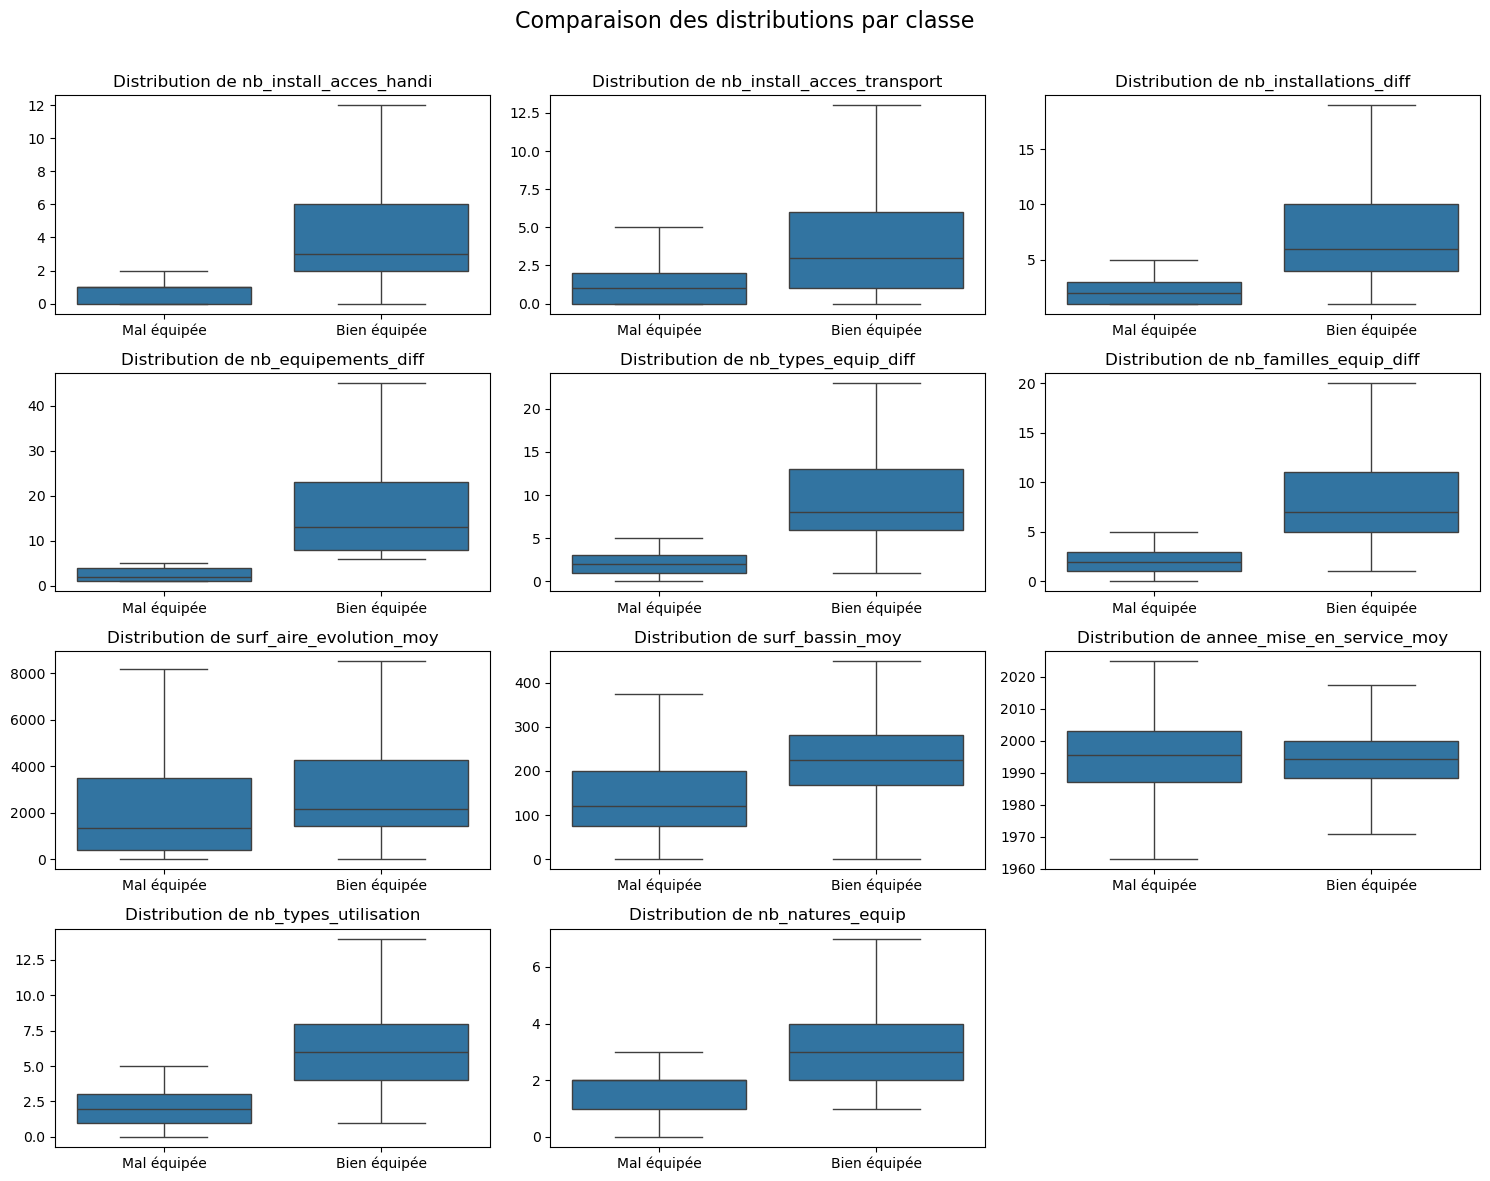

In [70]:
# Comparaison des distributions des variables entre les classes (bien/mal équipée)
# Séparation des données par classe
bien_equipees = tableau_communes[tableau_communes['bien_equipee'] == 1]
mal_equipees = tableau_communes[tableau_communes['bien_equipee'] == 0]

# Liste des colonnes numériques à analyser (ie toutes sauf 'commune' et 'bien_equipee')
colonnes_numeriques = tableau_communes.columns.drop(['commune', 'bien_equipee'])

plt.figure(figsize=(15, 12))
n_cols = 3
n_rows = (len(colonnes_numeriques) + n_cols - 1) // n_cols

# Création des boxplots comparatifs sans les outliers
for i, colonne in enumerate(colonnes_numeriques):
    plt.subplot(n_rows, n_cols, i+1)
    
    sns.boxplot(x='bien_equipee', y=colonne, data=tableau_communes, showfliers=False)

    plt.title(f'Distribution de {colonne}')
    plt.gca().set_xlabel('')
    plt.gca().set_ylabel('')
    plt.xticks([0, 1], ['Mal équipée', 'Bien équipée'])

plt.suptitle('Comparaison des distributions par classe', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [71]:
# Tableau comparatif des statistiques descriptives
stats_comparatives = pd.DataFrame()

for colonne in colonnes_numeriques:
    # Statistiques pour les communes bien équipées
    stats_bien = bien_equipees[colonne].describe()
    
    # Statistiques pour les communes mal équipées
    stats_mal = mal_equipees[colonne].describe()
    
    # Test de Student pour comparer les moyennes
    t_stat, p_val = stats.ttest_ind(bien_equipees[colonne].dropna(), 
                                   mal_equipees[colonne].dropna(),
                                   equal_var=False)
    
    # Création d'une ligne pour le tableau comparatif
    stats_comp = pd.DataFrame({
        'Variable': [colonne],
        'Moyenne (bien)': [stats_bien['mean']],
        'Moyenne (mal)': [stats_mal['mean']],
        'Médiane (bien)': [stats_bien['50%']],
        'Médiane (mal)': [stats_mal['50%']],
        'Écart-type (bien)': [stats_bien['std']],
        'Écart-type (mal)': [stats_mal['std']],
        'Diff. moyenne (%)': [(stats_bien['mean'] - stats_mal['mean']) / stats_mal['mean'] * 100 if stats_mal['mean'] != 0 else np.nan],
        'p-value': [p_val]
    })
    
    stats_comparatives = pd.concat([stats_comparatives, stats_comp])

# Formatage et affichage du tableau
stats_comparatives = stats_comparatives.sort_values('Diff. moyenne (%)', ascending=False)
stats_comparatives['Significatif'] = stats_comparatives['p-value'] < 0.05
stats_comparatives = stats_comparatives.reset_index(drop=True)
display(stats_comparatives.style.format({
    'Moyenne (bien)': '{:.2f}',
    'Moyenne (mal)': '{:.2f}',
    'Médiane (bien)': '{:.2f}',
    'Médiane (mal)': '{:.2f}',
    'Écart-type (bien)': '{:.2f}',
    'Écart-type (mal)': '{:.2f}',
    'Diff. moyenne (%)': '{:.1f}%',
    'p-value': '{:.4f}'
}))

,Variable,Moyenne (bien),Moyenne (mal),Médiane (bien),Médiane (mal),Écart-type (bien),Écart-type (mal),Diff. moyenne (%),p-value,Significatif
0,nb_equipements_diff,22.49,2.67,13.00,2.00,38.83,1.38,743.2%,0.0000,True
1,nb_install_acces_handi,5.17,0.93,3.00,1.00,8.74,0.95,454.9%,0.0000,True
2,nb_installations_diff,9.42,1.97,6.00,2.00,13.81,1.02,377.9%,0.0000,True
3,nb_types_equip_diff,10.73,2.34,8.00,2.00,7.59,1.19,358.4%,0.0000,True
4,nb_familles_equip_diff,8.34,2.21,7.00,2.00,4.26,1.15,277.7%,0.0000,True
5,nb_install_acces_transport,4.52,1.30,3.00,1.00,5.69,1.11,248.7%,0.0000,True
6,nb_types_utilisation,6.34,1.97,6.00,2.00,2.95,1.01,222.2%,0.0000,True
7,nb_natures_equip,3.16,1.64,3.00,2.00,0.99,0.71,93.1%,0.0000,True
8,surf_aire_evolution_moy,18350.20,14542.11,2135.52,1320.33,310978.30,402954.19,26.2%,0.4021,False
9,surf_bassin_moy,240.41,197.07,225.00,119.50,191.54,326.99,22.0%,0.1663,False


*Remarque :* Quasiment tous les tests de Student sont significatifs, y compris pour la variable 'annee_mise_en_service_moy' alors que les moyennes sont proches (Diff. moyenne = -0.0%) et que les boxplots montrent un chevauchement.  
Trois points importants :  
- Pour des années, exprimer la différence en pourcentage n'est pas très informatif - une différence absolue en années (1994.32 - 1993.83) est plus pertinente ; 
- Pour rappel, le code employé pour générer les boxplots utilise showfliers=False, ce qui masque les valeurs extrêmes. Cela donne l'impression d'un chevauchement plus important qu'il ne l'est réellement pour cette variable pour laquelle de nombreuses années très anciennes sont recensées dans les communes mal équipées *(vous pouvez vous en rendre compte en supprimant showfliers=False dans le code des boxplots)* ;
- Mais surtout, **la taille d'échantillon très importante** : avec un échantillon total de plus de 27000 communes, le test de Student devient extrêmement sensible et peut détecter des différences minuscules qui ne sont pas nécessairement pertinentes en pratique (une différence de 5.47 ans étant faible).

#### 4.1.2. Analyse de corrélation
**Objectif :** Déterminer si certaines variables sont redondantes ou inutiles.

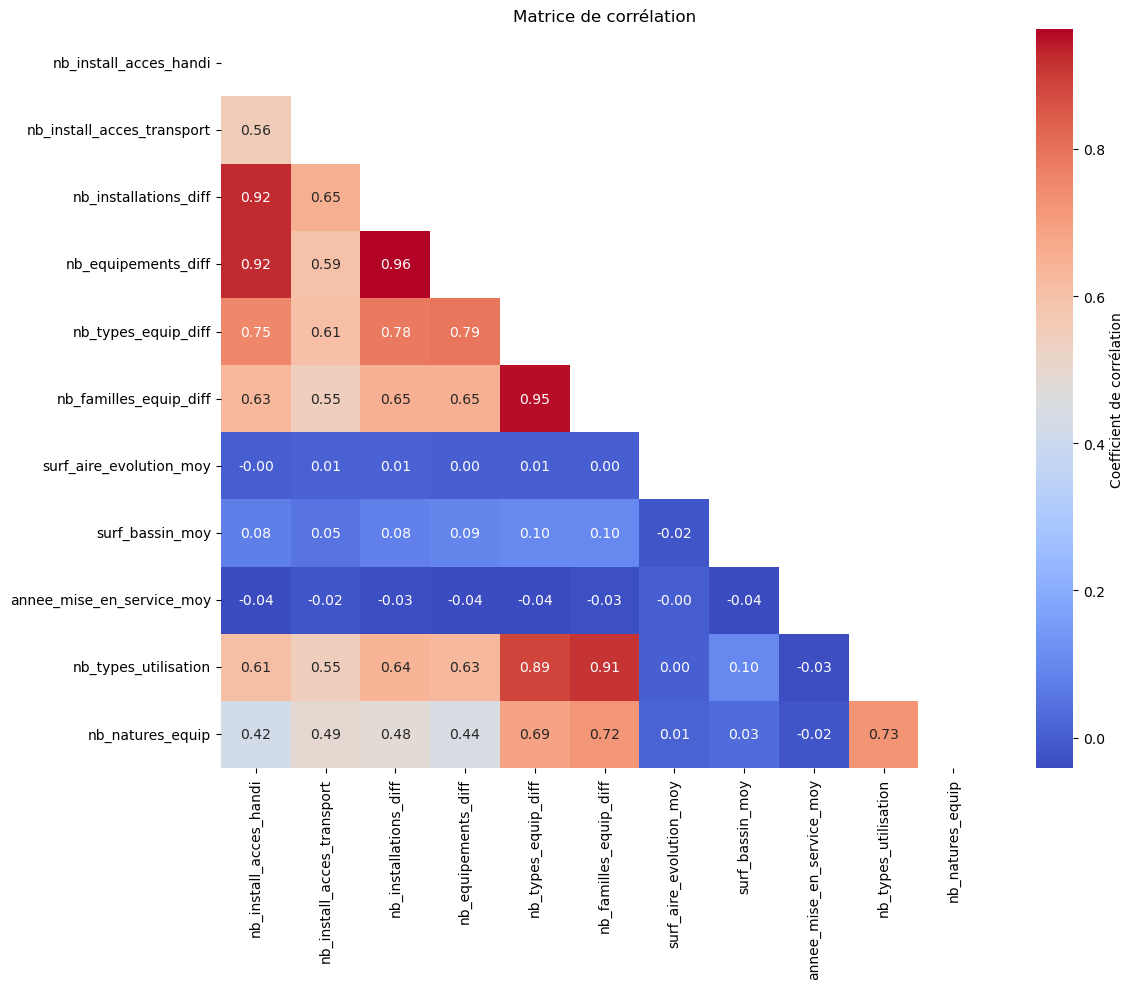

In [72]:
# Matrice de corrélation entre variables explicatives
corr_matrix = tableau_communes[list(colonnes_numeriques)].corr()
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'label': 'Coefficient de corrélation'})
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

Contrairement aux méthodes linéaires, **les Random Forests sont relativement robustes face aux variables corrélées.**  
En effet, elles sélectionnent de manière aléatoire un sous-ensemble de variables à chaque division de nœud, ce qui limite naturellement l’impact des corrélations. Il n’est donc pas toujours nécessaire de supprimer les variables corrélées en amont.  

Cependant, la présence de variables fortement corrélées peut réduire la diversité entre les arbres, biaiser l’estimation de l’importance des variables (celle-ci étant partagée entre des variables similaires), et compliquer l’interprétation des résultats.  

Dans cette étude, l’objectif principal étant la **performance prédictive** plutôt que l’interprétabilité, il n’est pas prioritaire de supprimer systématiquement les variables corrélées.  
Néanmoins, deux variables fortement corrélées apparaissent comme redondantes, notamment en raison de la construction du plan d’échantillonnage : 'nb_installations_diff' et 'nb_familles_equip_diff' (cette dernière étant en grande partie couverte par 'nb_types_equip_diff'). Leur apport étant limité pour la compréhension globale, **elles seront retirées de l’analyse**.


***Attention également :*** 'nb_equipements_diff' (impliqué dans la construction de la variable cible Y) est fortement corrélé à 'nb_install_acces_handi'. Il est préférable de retirer également 'nb_install_acces_handi' pour éviter la fuite de données (data leakage) évoquée précédemment (de façon indirecte, via la corrélation).

In [73]:
# Suppression des variables 'nb_installations_diff' et 'nb_familles_equip_diff'
tableau_communes = tableau_communes.drop(columns=['nb_installations_diff', 'nb_familles_equip_diff', 'nb_install_acces_handi'])
tableau_communes.to_csv('tableau_communes.csv', index=False)

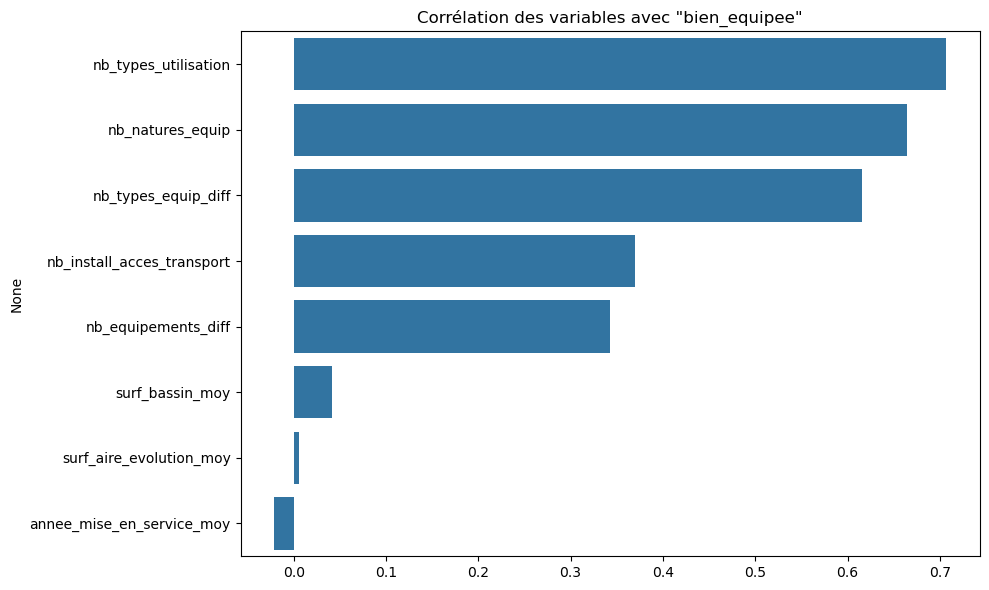

In [13]:
# Graphique en barres montrant la corrélation de chaque variable avec la variable cible 'bien_equipee'
corr_matrix = tableau_communes[list(colonnes_numeriques) + ['bien_equipee']].corr()
corr_avec_cible = corr_matrix['bien_equipee'].drop('bien_equipee').sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_avec_cible.values, y=corr_avec_cible.index)
plt.title('Corrélation des variables avec "bien_equipee"')
plt.tight_layout()
plt.show()

**Interprétation des corrélations avec la variable cible :**  
- Corrélations très fortes (>0.5) : Ces variables sont fortement associées à la variable cible : quand la variable augmente, la probabilité d’être bien équipée augmente aussi. Le modèle va probablement s'appuyer beaucoup sur ces variables.
- Corrélations modestes (0.3-0.5) : Ces variables ont un lien non négligeable avec la variable cible et sont probablement informatives ;
- Corrélations faibles (0.1-0.3) : Ces variables peuvent contenir de l'information utile, mais la relation est moins forte ;
- Corrélations très faibles (autour de 0) : Ces variables semblent avoir peu de relation linéaire avec la cible, mais pourraient contribuer de façon non-linéaire.

Certaines corrélations linéaires sont très fortes, d'autres modestes à extrêmement faibles. Le Random Forest est un bon choix car **il peut détecter des patterns complexes (impliquant des relations non linéaires et des interactions)** que les corrélations simples ne révèlent pas (ex : en Random Forest, une variable peu corrélée seule peut parfois être utile en interaction). 

Il est normal et plutôt sain d’avoir des variables avec des corrélations diverses. Par ailleurs, un maximum à 0.7 montre qu’il y a de la place pour l’apprentissage : le modèle devra combiner différentes informations pour prédire, il n'a pas la réponse toute faite.  

Nous garderons l'ensemble des variables et réaliserons une analyse d'importance post-modélisation : après avoir construit le Random Forest, nous examinerons l'importance des variables (feature_importance_) et comparerons ce classement aux corrélations initiales pour voir si certaines variables faiblement corrélées se révèlent importantes dans le modèle.

### 4.2. Modélisation par Random Forest

In [14]:
# Préparation des données 
# Séparation des variables explicatives (X) et de la variable cible (y)
X = tableau_communes.drop(['commune', 'bien_equipee', 'nb_equipements_diff'], axis=1)
y = tableau_communes['bien_equipee']

# Normalisation des données
# Bien que les Random Forests ne nécessitent pas de normalisation, ceci est utile pour l'interprétation et peut améliorer les visualisations SHAP
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Séparation en ensembles d'entraînement et de test
# stratify=y pour garantir que la distribution des classes dans la variable cible (% de communes bien vs mal équipées) est préservée dans les deux ensembles
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=12, stratify=y
)

# Vérification de l'équilibre des classes (pas indispensable ici car les classes sont déjà équilibrées, mais rend la pipeline plus flexible et réutilisable pour d'autres analyses)
class_distribution = y.value_counts(normalize=True)
print("Distribution des classes:")
print(class_distribution)

# Si les classes sont déséquilibrées (< 30% pour une classe), on utilise des métriques adaptées
is_imbalanced = min(class_distribution) < 0.3

# Cross-validation initiale avec métriques adaptées
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Utilisation de métriques appropriées selon l'équilibre des classes
if is_imbalanced:
    scoring_metric = 'f1'  # F1-score est meilleur pour les classes déséquilibrées
else:
    scoring_metric = 'accuracy'  # Accuracy est bien pour les classes équilibrées

print(f"Utilisation de la métrique de scoring: {scoring_metric}")
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring=scoring_metric)
print(f"CV {scoring_metric.capitalize()}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Grille de paramètres étendue avec max_features
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]  # Ajout de max_features pour gérer les corrélations : voir commentaire ci-après
}

# Optimisation des hyperparamètres avec RandomizedSearchCV (trouve automatiquement les meilleurs hyperparamètres)
# contrairement à GridSearchCV qui teste toutes les combinaisons possibles (très coûteux), RandomizedSearchCV échantillonne aléatoirement un nombre fixe de combinaisons de paramètres
rf_random = RandomizedSearchCV(
    rf, 
    param_grid, 
    n_iter=25,  # Augmenté pour explorer plus de combinaisons 
    cv=5, # Chaque combinaison de paramètres est testée sur 5 divisions différentes des données
    random_state=12, 
    n_jobs=-1,
    scoring=scoring_metric
)

rf_random.fit(X_train, y_train)
best_rf = rf_random.best_estimator_ # Modèle Random Forest configuré avec les meilleurs paramètres trouvés

print("Meilleurs paramètres trouvés:")
print(rf_random.best_params_)

# Évaluation complète du meilleur modèle identifié sur l'ensemble test avec métriques multiples
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]  # Probabilités pour la classe positive

# Métriques d'évaluation multiples
print("\n--- Évaluation du modèle ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}") # Proportion totale de prédictions correctes
print(f"Precision: {precision_score(y_test, y_pred):.4f}") # Parmi les communes prédites comme "bien équipées", combien le sont réellement
print(f"Recall: {recall_score(y_test, y_pred):.4f}") # Parmi les communes réellement "bien équipées", combien ont été correctement identifiées
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}") # Moyenne harmonique de la précision et du recall
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}") # Mesure de la capacité du modèle à distinguer les deux classes

Distribution des classes:
bien_equipee
False    0.512647
True     0.487353
Name: proportion, dtype: float64
Utilisation de la métrique de scoring: accuracy
CV Accuracy: 0.9319 ± 0.0034
Meilleurs paramètres trouvés:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30}

--- Évaluation du modèle ---
Accuracy: 0.9363
Precision: 0.9410
Recall: 0.9274
F1-Score: 0.9342
ROC AUC: 0.9840


In [15]:
print(X.columns.tolist()) # Pour rappel : variables explicatives

['nb_install_acces_transport', 'nb_types_equip_diff', 'surf_aire_evolution_moy', 'surf_bassin_moy', 'annee_mise_en_service_moy', 'nb_types_utilisation', 'nb_natures_equip']


#### 4.2.1. Remarques sur la construction du modèle

##### Le paramètre max_features
Le paramètre max_features est particulièrement important dans un modèle Random Forest, surtout lorsqu'on travaille avec des variables corrélées.  
Ce paramètre contrôle le nombre de variables (features) que chaque arbre de décision considère lors de la recherche du meilleur split à chaque nœud.   

**Options testées dans notre grille :**
- 'sqrt' : À chaque split, le modèle considère la racine carrée du nombre total de variables ;
- 'log2' : Considère le logarithme en base 2 du nombre total de variables ;
- None : Utilise toutes les variables disponibles à chaque split.

Quand des variables sont corrélées, comme dans notre cas, utiliser toujours toutes les variables (max_features=None) conduit à ce que les arbres aient tendance à choisir des variables similaires, réduisant la diversité du modèle.  
En limitant aléatoirement le nombre de variables (max_features='sqrt' ou 'log2'), on force le modèle à explorer d'autres variables qui pourraient être informatives mais normalement masquées par les variables dominantes. La diversification des variables utilisées dans les différents arbres est un principe fondamental des Random Forests, contribuant à leur robustesse.  

C'est l'option 'None' qui a été sélectionnée comme optimale dans notre cas, ce qui est intéressant. Cela suggère que :
- Toutes les variables conservées (après élimination de deux variables suite à l'analyse des corrélations) contiennent de l'information utile pour la prédiction ;
- La relation entre variables explicatives et variable cible est suffisamment forte pour que l'utilisation de toutes les variables à chaque split améliore les performances.  

##### Validation croisée initiale
Ici, nous évaluons d'abord notre modèle avec cross-validation pour avoir une estimation robuste des performances (entraînement et évaluation du modèle sur 5 sous-ensembles train/test différents).

##### Optimisation des hyperparamètres
L'utilisation de RandomizedSearchCV avec une grille de paramètres permet de trouver le meilleur modèle tout en étant plus efficace qu'une recherche exhaustive.

#### 4.2.2. Interprétation des premières sorties

##### Distribution des classes
Nos données sont bien équilibrées : 51.26% de communes "mal équipées" et 48.74% de communes "bien équipées" (*Rappel : cette distribution proche de 50/50 est idéale pour l'apprentissage et évite les biais de classification*).  

##### Performance du modèle
Les résultats du modèle sont très bons.
- **Accuracy (93.63%)** : Le modèle prédit correctement le statut d'équipement de plus de 93% des communes, ce qui est excellent ;
- **Precision (94.10%)** : Parmi les communes que le modèle identifie comme "bien équipées", 94.10% le sont réellement ;
- **Recall (92.74%)** : Le modèle identifie correctement 92.74% des communes qui sont véritablement "bien équipées" ;
- **F1-Score (93.42%)** : Bonne moyenne harmonique entre precision et recall ;
- **ROC AUC (98.40%)** : Score exceptionnellement haut montrant que le modèle distingue très bien les deux classes.  

##### Meilleurs hyperparamètres
Le modèle a retenu un nombre modéré d'arbres (n_estimators=100), une profondeur maximale assez importante (max_depth=30), une faible valeur pour min_samples_split=2 et une valeur modérée pour min_samples_leaf=4.  
L'utilisation de max_features='sqrt' montre que limiter le nombre de caractéristiques considérées à chaque split est bénéfique.  

##### Interprétation générale
Notre modèle est très performant pour prédire si une commune est "bien équipée" en se basant sur les 7 variables explicatives que nous avons conservées. Cela suggère que ces variables capturent efficacement les facteurs déterminants pour cette classification, sans nécessiter d'autres variables qui pourraient introduire un data leakage.

Ces excellents résultats s'expliquent notamment par le fait que le statut "bien équipée" d'une commune soit fortement lié aux variables explicatives utilisées (qui sont très liées au concept d'équipements). Par exemple, 'nb_types_equip_diff' capture une information similaire mais pas identique à notre critère de définition basé sur 'nb_equipements_diff'.

#### 4.2.3. Approfondissement de l'analyse : matrice de confusion et importance des variables

In [16]:
# Matrice de confusion 
cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(cm)
# 2616 vrais négatifs, 191 faux négatifs, 153 faux positifs, 2441 vrais positifs

Matrice de confusion :
[[2616  153]
 [ 191 2441]]


In [17]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# Modèle très performant pour les deux classes (bien/mal équipées)


Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.94      0.94      2769
        True       0.94      0.93      0.93      2632

    accuracy                           0.94      5401
   macro avg       0.94      0.94      0.94      5401
weighted avg       0.94      0.94      0.94      5401



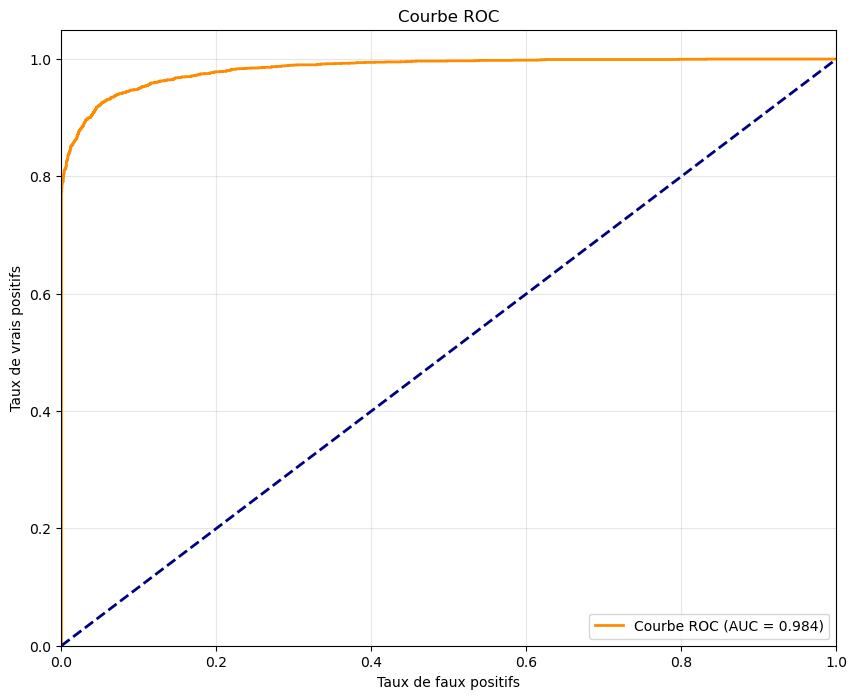

In [18]:
# Visualisation de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

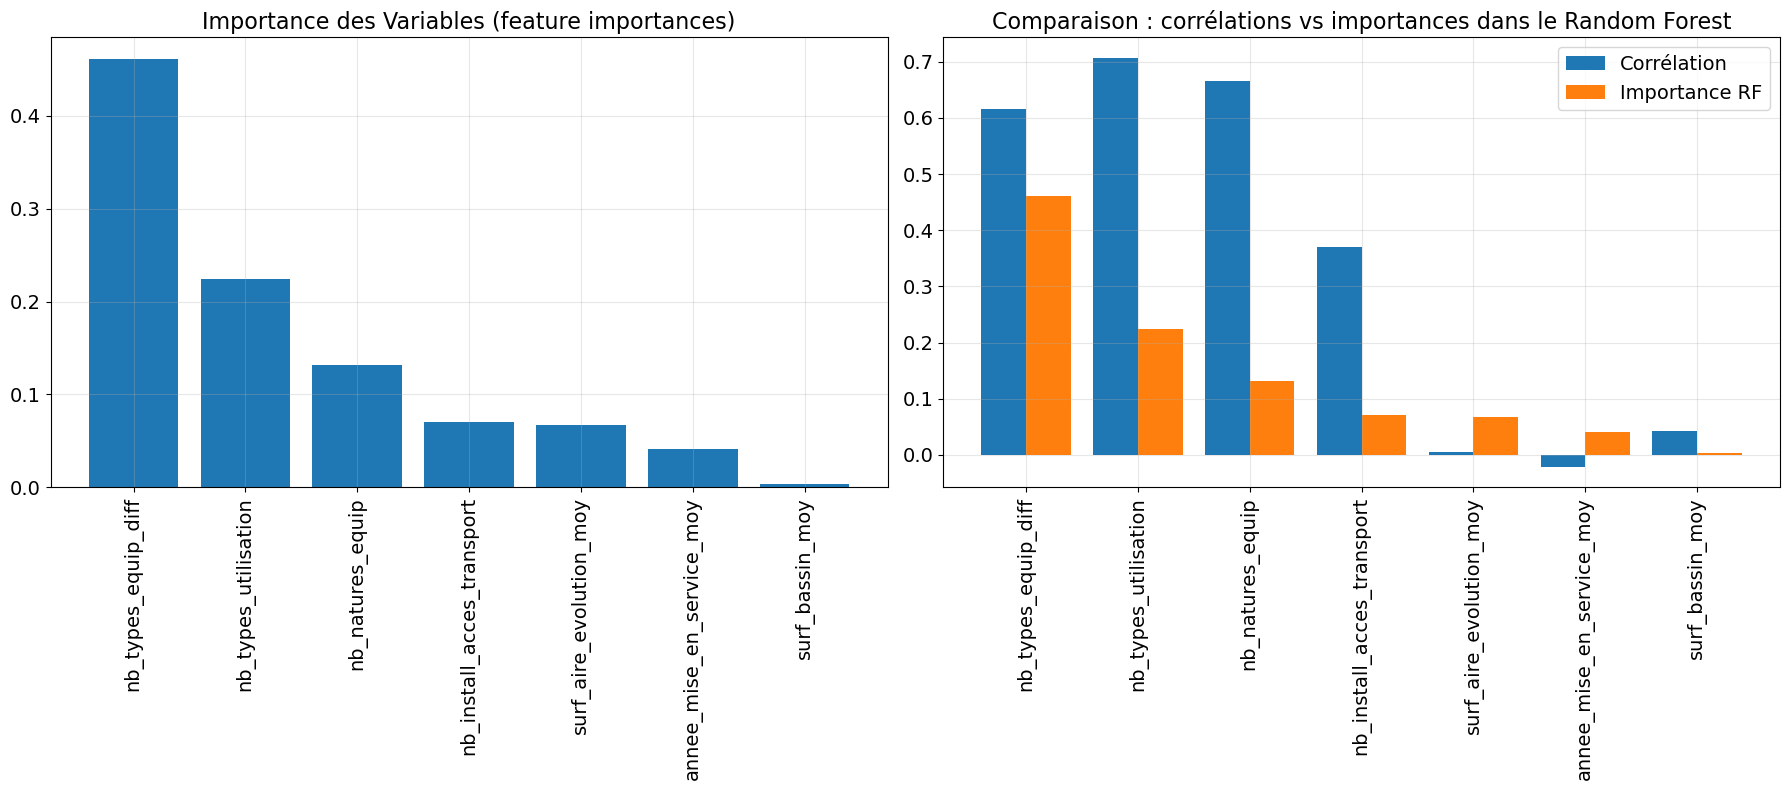

In [19]:
# Première figure : Importance des variables (interprétation avec feature_importances)
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Deuxième figure : Comparaison des importances des variables avec les corrélations initiales
corr_avec_cible = tableau_communes[list(X.columns) + ['bien_equipee']].corr()['bien_equipee'].drop('bien_equipee')

# Création du dataframe pour comparer les corrélations et les importances
comparison_df = pd.DataFrame({
    'Variable': X.columns,
    'Correlation': corr_avec_cible,
    'Importance': best_rf.feature_importances_
})
comparison_df = comparison_df.sort_values('Importance', ascending=False)

# Création des subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))  

# Premier plot
axes[0].bar(range(X_train.shape[1]), importances[indices], align='center')
axes[0].set_title('Importance des Variables (feature importances)', fontsize=16)
axes[0].set_xticks(range(X_train.shape[1]))
axes[0].set_xticklabels([X_train.columns[i] for i in indices], rotation=90, fontsize=14)
axes[0].tick_params(axis='y', labelsize=14)
axes[0].grid(True, alpha=0.3)

# Deuxième plot
width = 0.4
idx = np.arange(len(comparison_df))
axes[1].bar(idx - width/2, comparison_df['Correlation'], width, label='Corrélation')
axes[1].bar(idx + width/2, comparison_df['Importance'], width, label='Importance RF')
axes[1].set_xticks(idx)
axes[1].set_xticklabels(comparison_df['Variable'], rotation=90, fontsize=14)
axes[1].tick_params(axis='y', labelsize=14)
axes[1].legend(fontsize=14)
axes[1].set_title('Comparaison : corrélations vs importances dans le Random Forest', fontsize=16)
axes[1].grid(True, alpha=0.3)

# Ajustement des layouts
plt.tight_layout()
plt.show()

Les variables "importantes" (resp. moins "importantes") sont celles pour lesquelles une forte (resp. faible) corrélation avec la variable cible, ainsi qu'avec 'nb_equipements_diff' (impliquée dans la construction de la variable cible), avait été identifiée dans la partie 4.1.2.

In [20]:
# SHAP pour une interprétation plus fine
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(X_test)

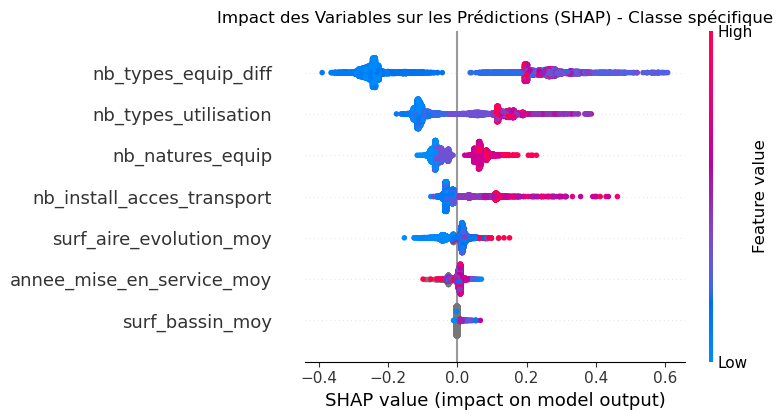

In [28]:
# SHAP values détaillées : impact de chaque variable
plt.figure(figsize=(12, 10))
shap.plots.beeswarm(shap_values[:,:,1], show=False, max_display=20) # L'index 1 pour un classificateur binaire renvoie directement à la classe positive (ie communes bien équipées)
plt.title('Impact des variables sur les prédictions vers la classe "bien équipée" (SHAP)')
plt.tight_layout()
plt.show()

Une **valeur SHAP** mesure la contribution de chaque variable à la prédiction pour une observation spécifique, par rapport à une valeur de base (la prédiction moyenne du modèle).  
Les valeurs SHAP distribuent équitablement l'importance entre les variables, même quand elles sont corrélées, contrairement aux méthodes d'importance de variables traditionnelles.  

La visualisation proposée montre :
- L'importance des variables (axe vertical, de la plus importante en haut à la moins importante en bas) ;
- La distribution des valeurs SHAP pour chaque variable (axe horizontal) ; 
- La valeur de chaque observation (rouge = valeur élevée, bleu = valeur faible).

Pour chaque variable :  
Les points représentent des observations individuelles (communes) ;  
La position horizontale indique si cette variable augmente (valeur SHAP positive) ou diminue (valeur SHAP négative) la probabilité que la commune soit classée comme "bien équipée" (à droite, ie pour des valeurs SHAP positives, la variable pousse la prédiction vers la classe "commune bien équipée" ; inversement à gauche).  
La couleur indique si la valeur de la variable est élevée (rouge) ou faible (bleu).  
*Remarque : Les points sont empilés verticalement pour chaque variable, la distribution verticale montrant donc la densité des observations à différentes valeurs SHAP.*  

*Exemple 1 :* l'amas de points rouges à droite pour la variable 'nb_natures_equip' indique qu'une grande diversité de natures d'équipements sportifs pousse fortement vers la classe "commune bien équipée".  
*Exemple 2 :* l'amas de points bleus à gauche pour la variable 'nb_types_equip_diff' montre qu'un faible nombre de types d'équipements différents augmente fortement la probabilité qu'une commune soit classée comme "mal équipée".

Plus finement, si une commune a une valeur SHAP de +0.2 (resp. de -0.1) pour une variable, cela signifie que cette variable augmente de 0.2 (resp. réduit de 0.1) la probabilité que cette commune soit classée comme "bien équipée" par rapport à la moyenne.

## Partie 2 : *Classification automatique des communes "bien équipées" vs "mal équipées" sur la base de caractéristiques démographiques*
**Rappel du but :** Créer un modèle qui apprend à **prédire** si une commune est bien équipée en infrastructures sportives ou non, en se basant sur des caractéristiques non liées à ses équipements sportifs directement mais sur des **indicateurs socio-territoriaux**.

Données brutes directement collectées sur le site de l'INSEE : https://statistiques-locales.insee.fr/#view=map1&c=indicator

**Caractéristiques sélectionnées** (dates de collecte des données) :
- **Démographie - évolution et structure de la population** : Population municipale (2022) ; Densité de population (2021) ; Indice de vieillissement (2021).  
*Indice de viellissement : Rapport de la population des 65 ans et plus sur celle des moins de 20 ans (observatoire-des-territoires.gouv.fr).*
- **Démographie - Naissance, fécondité** : Taux de natalité annuel moyen (2015-2021).  
- **Démographie - Couples, familles, ménages** : Part des personnes de 15 ans ou plus célibataires (2021) ; Taille moyenne des ménages (2021).  
*Ménage : Ensemble des occupants d'un même logement sans que ces personnes soient nécessairement unies par des liens de parenté (insee.fr).*  
*Remarque : La situation de vie familiale ou le niveau de socialisation peut influencer la motivation à faire de l'activité physique.*

- **Revenus, pouvoir d'achat, consommation** : Médiane du niveau de vie (2021).  
*Médiane du niveau de vie : Niveau au-dessus duquel se situent 50 % des revenus (observatoire-des-territoires.gouv.fr).*  
*Remarque : Les communes les plus pauvres peuvent être moins bien équipées en infrastructures sportives ou avoir d'autres priorités budgétaires.*  

- **Conditions de vie, société - Education, formation, compétences** : Part (%) des non ou peu diplômés dans la population non scolarisée de 15 ans ou plus (2021) ; Part (%) des diplômés d'un BAC+5 ou plus dans la population non scolarisée de 15 ans ou plus (2021).  
*Remarque : Une corrélation positive est établie entre niveau de diplôme et intensité de la pratique sportive.*  
- **Conditions de vie, société - Logement** : Part des résidences secondaires (y compris les logements occasionnels) dans le nombre total de logements (2021) ; Part (%) des logements vacants dans le nombre total de logements (2021).  
*Remarque : Les villes avec de nombreuses résidences secondaires peuvent voir leurs services publics sous-dimensionnés ou réduits hors saison, ce qui peut affecter l’attractivité pour les familles ou les jeunes actifs ; le taux de logements vacants peut être témoin d'une perte d'attractivité du territoire.*

- **Marché du travail, salaires** : Taux d'activité (2021).
*Taux d'activité : Rapport entre le nombre d’actifs et l’ensemble de la population correspondante (insee.fr).*  
*Remarque : L'activité professionnelle (resp. l'absence d'activité professionnelle) influence le temps libre et la capacité financière à pratiquer une activité sportive.*  

- **Démographie et création des entreprises** : Nombre d'unités légales (2022) - Nombre de créations d'entreprises (2023).  
*Unité légale : Entité juridique de droit public ou privé [pouvant] être une personne morale [ou] physique, qui, en tant qu'indépendant, peut exercer une activité économique (insee.fr).*

- **Secteurs d'activité - Tourisme** : Nombre d'hôtels (2025) ; Nombre de terrains de camping (2025).  
*Remarque : Une ville prospérant par le tourisme peut avoir la volonté d'investir dans les infrastructures sportives ou voir s'établir une corrélation naturelle entre équipement touristique et équipement de loisir, dont sportif.*

- **Territoires, villes et quartiers - Equipements et services à la population** : Nombre d'écoles maternelles, primaires et élémentaires (2023) - Nombre de collèges (2023) - Nombre de lycées (2023).  
*Remarque : Les écoles utilisent souvent les équipements sportifs, leur nombre pouvant être un indicateur de pression sur l'offre.*  
- **Territoires, villes et quartiers - Mobilités, déplacements** : Part (%) des actifs occupés de 15 ans ou plus qui utilisent principalement les transports en commun pour aller travailler (2021).  
*Remarque : Postulat qu'une personne utilisant les transports en commun pour le travail est à même de les utiliser pour d'autres de ses activités, dont le sport ; l'accessibilité aux équipements peut être une limite à l'usage.*


L'objectif est donc, via un modèle random forest, de mettre en évidence des relations prédictives (potentiellement non linéaires ou multivariées) entre ces variables et le caractère bien/mal équipé en infrastructures sportives d'une commune. Autrement dit, il s'agit de voir si le modèle peut prédire, sur la base de ces critères, quelles communes sont bien équipées en infrastructures sportives.

## 1. Chargement et nettoyage des données
### 1.1 Chargement des données

In [24]:
# Chargement du fichier (données collectées pour l'ensemble des communes étudiées par l'INSEE, ie 34 935 communes)
df_insee = pd.read_csv("data-insee.csv", sep=';', skiprows=2, low_memory=False) 
df_insee.shape

(34935, 22)

In [25]:
display(df_insee.head())

,Code,Libellé,Part des logements vacants dans le total des logements 2021,Population municipale 2022,Densité de population (historique depuis 1876) 2021,Indice de vieillissement 2021,Part des pers. de 15 ans ou + célibataires 2021,Taille moyenne des ménages 2021,Taux de natalité annuel moyen 2015-2021,Médiane du niveau de vie 2021,...,Part des rés. secondaires (y compris les logements occasionnels) dans le total des logements 2021,Taux d'activité par tranche d'âge 2021,Unités légales (en nombre) 2022,Créations d'entreprises (en nombre) 2023,Nb d'hôtels 2025,Nb de terrains de camping 2025,"École maternelle, primaire, élémentaire (en nombre) 2023",Collège (en nombre) 2023,Lycée (en nombre) 2023,Part des actifs occupés de 15 ans ou plus les transports en commun 2021
0,01001,L'Abergement-Clémenciat,4.7,859,52.2,79.9,15.4,2.44,10.9,25820,...,3.7,82.1,54,16,0,0,1,0,0,1
1,01002,L'Abergement-de-Varey,8.1,273,29.2,60.7,21,2.31,11.9,24480,...,25.7,79.9,20,3,0,0,0,0,0,5.1
2,01004,Ambérieu-en-Bugey,9.9,15554,603.8,70.6,27.3,2.07,15.4,21660,...,1.8,76.1,1148,209,1,0,7,2,2,13.5
3,01005,Ambérieux-en-Dombes,10.7,1917,119.2,68.2,20,2.39,10.7,24610,...,0.8,81.3,160,22,2,1,1,0,0,3
4,01006,Ambléon,9.7,114,19.2,228.6,19.2,2,9,24210,...,12.9,70.8,4,2,0,0,0,0,0,0


### 1.2. Nettoyage des données

In [26]:
# Liste complète des colonnes
# for i, col in enumerate(df_insee.columns, 1):
    # print(f"{i:3d}. {col}")

In [27]:
df_insee.columns = ['code_INSEE', 'commune', 'part_logements_vacants', 'pop_municipale', 'densite_de_pop', 
                    'indice_vieillissement', 'part_celib', 'taille_moy_menages', 'tx_nat_annuel_moy', 'niveau_de_vie_median', 
                    'part_peu_non_diplomes', 'part_bac+5', 'part_resid_secondaires', 'tx_activite', 'entreprises_unites_legales', 
                    'creations_entreprises', 'nb_hotels', 'nb_terrains_camping', 'nb_ecoles', 'nb_colleges', 'nb_lycees', 
                    'part_actifs_utilisant_transp_commun']
display(df_insee.head())

,code_INSEE,commune,part_logements_vacants,pop_municipale,densite_de_pop,indice_vieillissement,part_celib,taille_moy_menages,tx_nat_annuel_moy,niveau_de_vie_median,...,part_resid_secondaires,tx_activite,entreprises_unites_legales,creations_entreprises,nb_hotels,nb_terrains_camping,nb_ecoles,nb_colleges,nb_lycees,part_actifs_utilisant_transp_commun
0,01001,L'Abergement-Clémenciat,4.7,859,52.2,79.9,15.4,2.44,10.9,25820,...,3.7,82.1,54,16,0,0,1,0,0,1
1,01002,L'Abergement-de-Varey,8.1,273,29.2,60.7,21,2.31,11.9,24480,...,25.7,79.9,20,3,0,0,0,0,0,5.1
2,01004,Ambérieu-en-Bugey,9.9,15554,603.8,70.6,27.3,2.07,15.4,21660,...,1.8,76.1,1148,209,1,0,7,2,2,13.5
3,01005,Ambérieux-en-Dombes,10.7,1917,119.2,68.2,20,2.39,10.7,24610,...,0.8,81.3,160,22,2,1,1,0,0,3
4,01006,Ambléon,9.7,114,19.2,228.6,19.2,2,9,24210,...,12.9,70.8,4,2,0,0,0,0,0,0


In [28]:
df_insee.replace('N/A - résultat non disponible', np.nan, inplace=True)
df_insee.replace('N/A - division par 0', np.nan, inplace=True)

In [29]:
# Affichage du nombre de NA pour les colonnes concernées via une bouche qui parcourt chaque colonne
for colonne in df_insee.columns:
    # Compter le nombre de NA
    nombre_na = df_insee[colonne].isna().sum()
    
    # Afficher un message uniquement si la colonne contient des NA
    if nombre_na > 0:
        print(f"La colonne '{colonne}' contient {nombre_na} valeurs NA")

La colonne 'part_logements_vacants' contient 22 valeurs NA
La colonne 'pop_municipale' contient 17 valeurs NA
La colonne 'densite_de_pop' contient 17 valeurs NA
La colonne 'indice_vieillissement' contient 89 valeurs NA
La colonne 'part_celib' contient 26 valeurs NA
La colonne 'taille_moy_menages' contient 23 valeurs NA
La colonne 'tx_nat_annuel_moy' contient 23 valeurs NA
La colonne 'niveau_de_vie_median' contient 3676 valeurs NA
La colonne 'part_peu_non_diplomes' contient 26 valeurs NA
La colonne 'part_bac+5' contient 26 valeurs NA
La colonne 'part_resid_secondaires' contient 22 valeurs NA
La colonne 'tx_activite' contient 27 valeurs NA
La colonne 'entreprises_unites_legales' contient 209 valeurs NA
La colonne 'creations_entreprises' contient 3572 valeurs NA
La colonne 'nb_hotels' contient 17 valeurs NA
La colonne 'nb_terrains_camping' contient 17 valeurs NA
La colonne 'nb_ecoles' contient 3 valeurs NA
La colonne 'nb_colleges' contient 3 valeurs NA
La colonne 'nb_lycees' contient 3 va

In [30]:
# print(df_insee.dtypes)

In [31]:
# Modification du type des colonnes
df_insee = df_insee.astype({
    'code_INSEE': 'str', # Non pas un entier car certaines communes ont des codes incluant des lettres (ex : 2A004 pour Ajaccio)
    'commune': 'str',
    'part_logements_vacants': 'float',
    'pop_municipale': 'Int64',
    'densite_de_pop': 'float',
    'indice_vieillissement': 'float',
    'part_celib': 'float',
    'taille_moy_menages': 'float',
    'tx_nat_annuel_moy': 'float',
    'niveau_de_vie_median': 'Int64',
    'part_peu_non_diplomes': 'float',
    'part_bac+5': 'float',
    'part_resid_secondaires': 'float',
    'tx_activite': 'float',
    'entreprises_unites_legales': 'Int64',
    'creations_entreprises': 'Int64',
    'nb_hotels': 'Int64',
    'nb_terrains_camping': 'Int64',
    'nb_ecoles': 'Int64',
    'nb_colleges': 'Int64',
    'nb_lycees': 'Int64',
    'part_actifs_utilisant_transp_commun': 'float'
})

Certaines variables représentent des **effectifs** et non des proportions ; il est impératifs de les normaliser sur le nombre d'habitants de la commune (densité/ratios comparables entre communes de tailles différentes).  
Ici, ratios pour 1000 habitants.

In [32]:
# Transformation des effectifs en ratios
colonnes_a_normaliser = ['entreprises_unites_legales', 'creations_entreprises', 'nb_hotels', 'nb_terrains_camping', 
                         'nb_ecoles', 'nb_colleges', 'nb_lycees']

for colonne in colonnes_a_normaliser:
    df_insee[colonne] = df_insee[colonne] / df_insee['pop_municipale'] * 1000

In [33]:
display(df_insee.head())

,code_INSEE,commune,part_logements_vacants,pop_municipale,densite_de_pop,indice_vieillissement,part_celib,taille_moy_menages,tx_nat_annuel_moy,niveau_de_vie_median,...,part_resid_secondaires,tx_activite,entreprises_unites_legales,creations_entreprises,nb_hotels,nb_terrains_camping,nb_ecoles,nb_colleges,nb_lycees,part_actifs_utilisant_transp_commun
0,01001,L'Abergement-Clémenciat,4.7,859,52.2,79.9,15.4,2.44,10.9,25820,...,3.7,82.1,62.863795,18.62631,0.0,0.0,1.164144,0.0,0.0,1.0
1,01002,L'Abergement-de-Varey,8.1,273,29.2,60.7,21.0,2.31,11.9,24480,...,25.7,79.9,73.260073,10.989011,0.0,0.0,0.0,0.0,0.0,5.1
2,01004,Ambérieu-en-Bugey,9.9,15554,603.8,70.6,27.3,2.07,15.4,21660,...,1.8,76.1,73.807381,13.437058,0.064292,0.0,0.450045,0.128584,0.128584,13.5
3,01005,Ambérieux-en-Dombes,10.7,1917,119.2,68.2,20.0,2.39,10.7,24610,...,0.8,81.3,83.463745,11.476265,1.043297,0.521648,0.521648,0.0,0.0,3.0
4,01006,Ambléon,9.7,114,19.2,228.6,19.2,2.00,9.0,24210,...,12.9,70.8,35.087719,17.54386,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Fusion des dataframes

In [34]:
# Ajout dans le dataframe des équipements sportifs 'tableau_communes' des codes INSEE par jointure avec le dataframe historique 'df_corrige'
tableau_communes = pd.read_csv('tableau_communes.csv')
df_corrige = pd.read_csv('df_nettoye.csv')

df_codes_uniques = df_corrige.drop_duplicates(subset=['commune']) # Déduplication des communes du dataframe df_corrige

tableau_communes = tableau_communes.merge(
    df_codes_uniques[['commune', 'code_INSEE']], 
    on='commune', 
    how='left'
)

display(tableau_communes.head())

C:\Users\leaam\AppData\Local\Temp\ipykernel_23220\1397276489.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_corrige = pd.read_csv('df_nettoye.csv')


,commune,nb_install_acces_transport,nb_equipements_diff,nb_types_equip_diff,surf_aire_evolution_moy,surf_bassin_moy,annee_mise_en_service_moy,nb_types_utilisation,nb_natures_equip,bien_equipee,code_INSEE
0,Toulouse,200,1696,92,1871.362113,438.854839,1999.509910,29,7,True,31555
1,Reims,5,802,63,1171.459709,218.863636,1993.172840,16,6,True,51454
2,Nantes,7,765,61,1636.746207,271.300000,1985.200280,16,5,True,44109
3,Saint-Denis,36,714,67,1647.041357,261.000000,1995.335917,15,6,True,11339
4,Strasbourg,64,691,63,1475.021536,311.800000,1982.648054,19,6,True,67482


In [35]:
# Nettoyage de la colonne 'code_INSEE' de 'tableau_communes' : élimination des '.0' issus de flottants
tableau_communes['code_INSEE'] = (
    tableau_communes['code_INSEE']
    .astype(str)
    .str.replace(r'\.0$', '', regex=True)
)

In [36]:
# Fusion de df_insee et tableau_communes : ajout de la colonne "bien_equipee" à df_insee dans un nouveau dataframe
df_insee_equipement = df_insee.merge(
    tableau_communes[['bien_equipee', 'code_INSEE']], 
    on='code_INSEE', 
    how='inner' # df constitué des communes trouvées dans les deux df
)

print("Nombre de communes pour lesquelles une correspondance est trouvée :", df_insee_equipement.shape[0])
print("Nombre de communes bien équipées parmi ces", df_insee_equipement.shape[0], "communes :", len(df_insee_equipement[df_insee_equipement['bien_equipee'] == True]))
display(df_insee_equipement.head())
df_insee_equipement.to_csv('df_insee_equipement.csv', index=False)

Nombre de communes pour lesquelles une correspondance est trouvée : 24544
Nombre de communes bien équipées parmi ces 24544 communes : 11828


,code_INSEE,commune,part_logements_vacants,pop_municipale,densite_de_pop,indice_vieillissement,part_celib,taille_moy_menages,tx_nat_annuel_moy,niveau_de_vie_median,...,tx_activite,entreprises_unites_legales,creations_entreprises,nb_hotels,nb_terrains_camping,nb_ecoles,nb_colleges,nb_lycees,part_actifs_utilisant_transp_commun,bien_equipee
0,01006,Ambléon,9.7,114,19.2,228.6,19.2,2.00,9.0,24210,...,70.8,35.087719,17.54386,0.0,0.0,0.0,0.0,0.0,0.0,False
1,01101,Chevillard,14.8,149,22.5,89.7,16.0,2.20,11.9,26800,...,89.9,33.557047,13.422819,0.0,0.0,0.0,0.0,0.0,1.1,False
2,01166,Frans,2.8,2547,311.0,64.0,20.4,2.46,10.6,27060,...,81.9,76.168041,14.919513,0.0,0.0,0.392619,0.0,0.0,5.4,False
3,01169,Genouilleux,5.3,675,159.3,42.7,19.2,2.54,11.4,25500,...,81.0,68.148148,19.259259,0.0,0.0,1.481481,0.0,0.0,5.6,False
4,01260,Le Montellier,5.4,329,20.7,41.0,15.9,2.77,15.0,28850,...,83.6,85.106383,15.197568,0.0,0.0,3.039514,0.0,0.0,5.9,False


## 3. Modélisation par Random Forest

### 3.1. Analyses préalables
#### 3.1.1. Statistiques descriptives

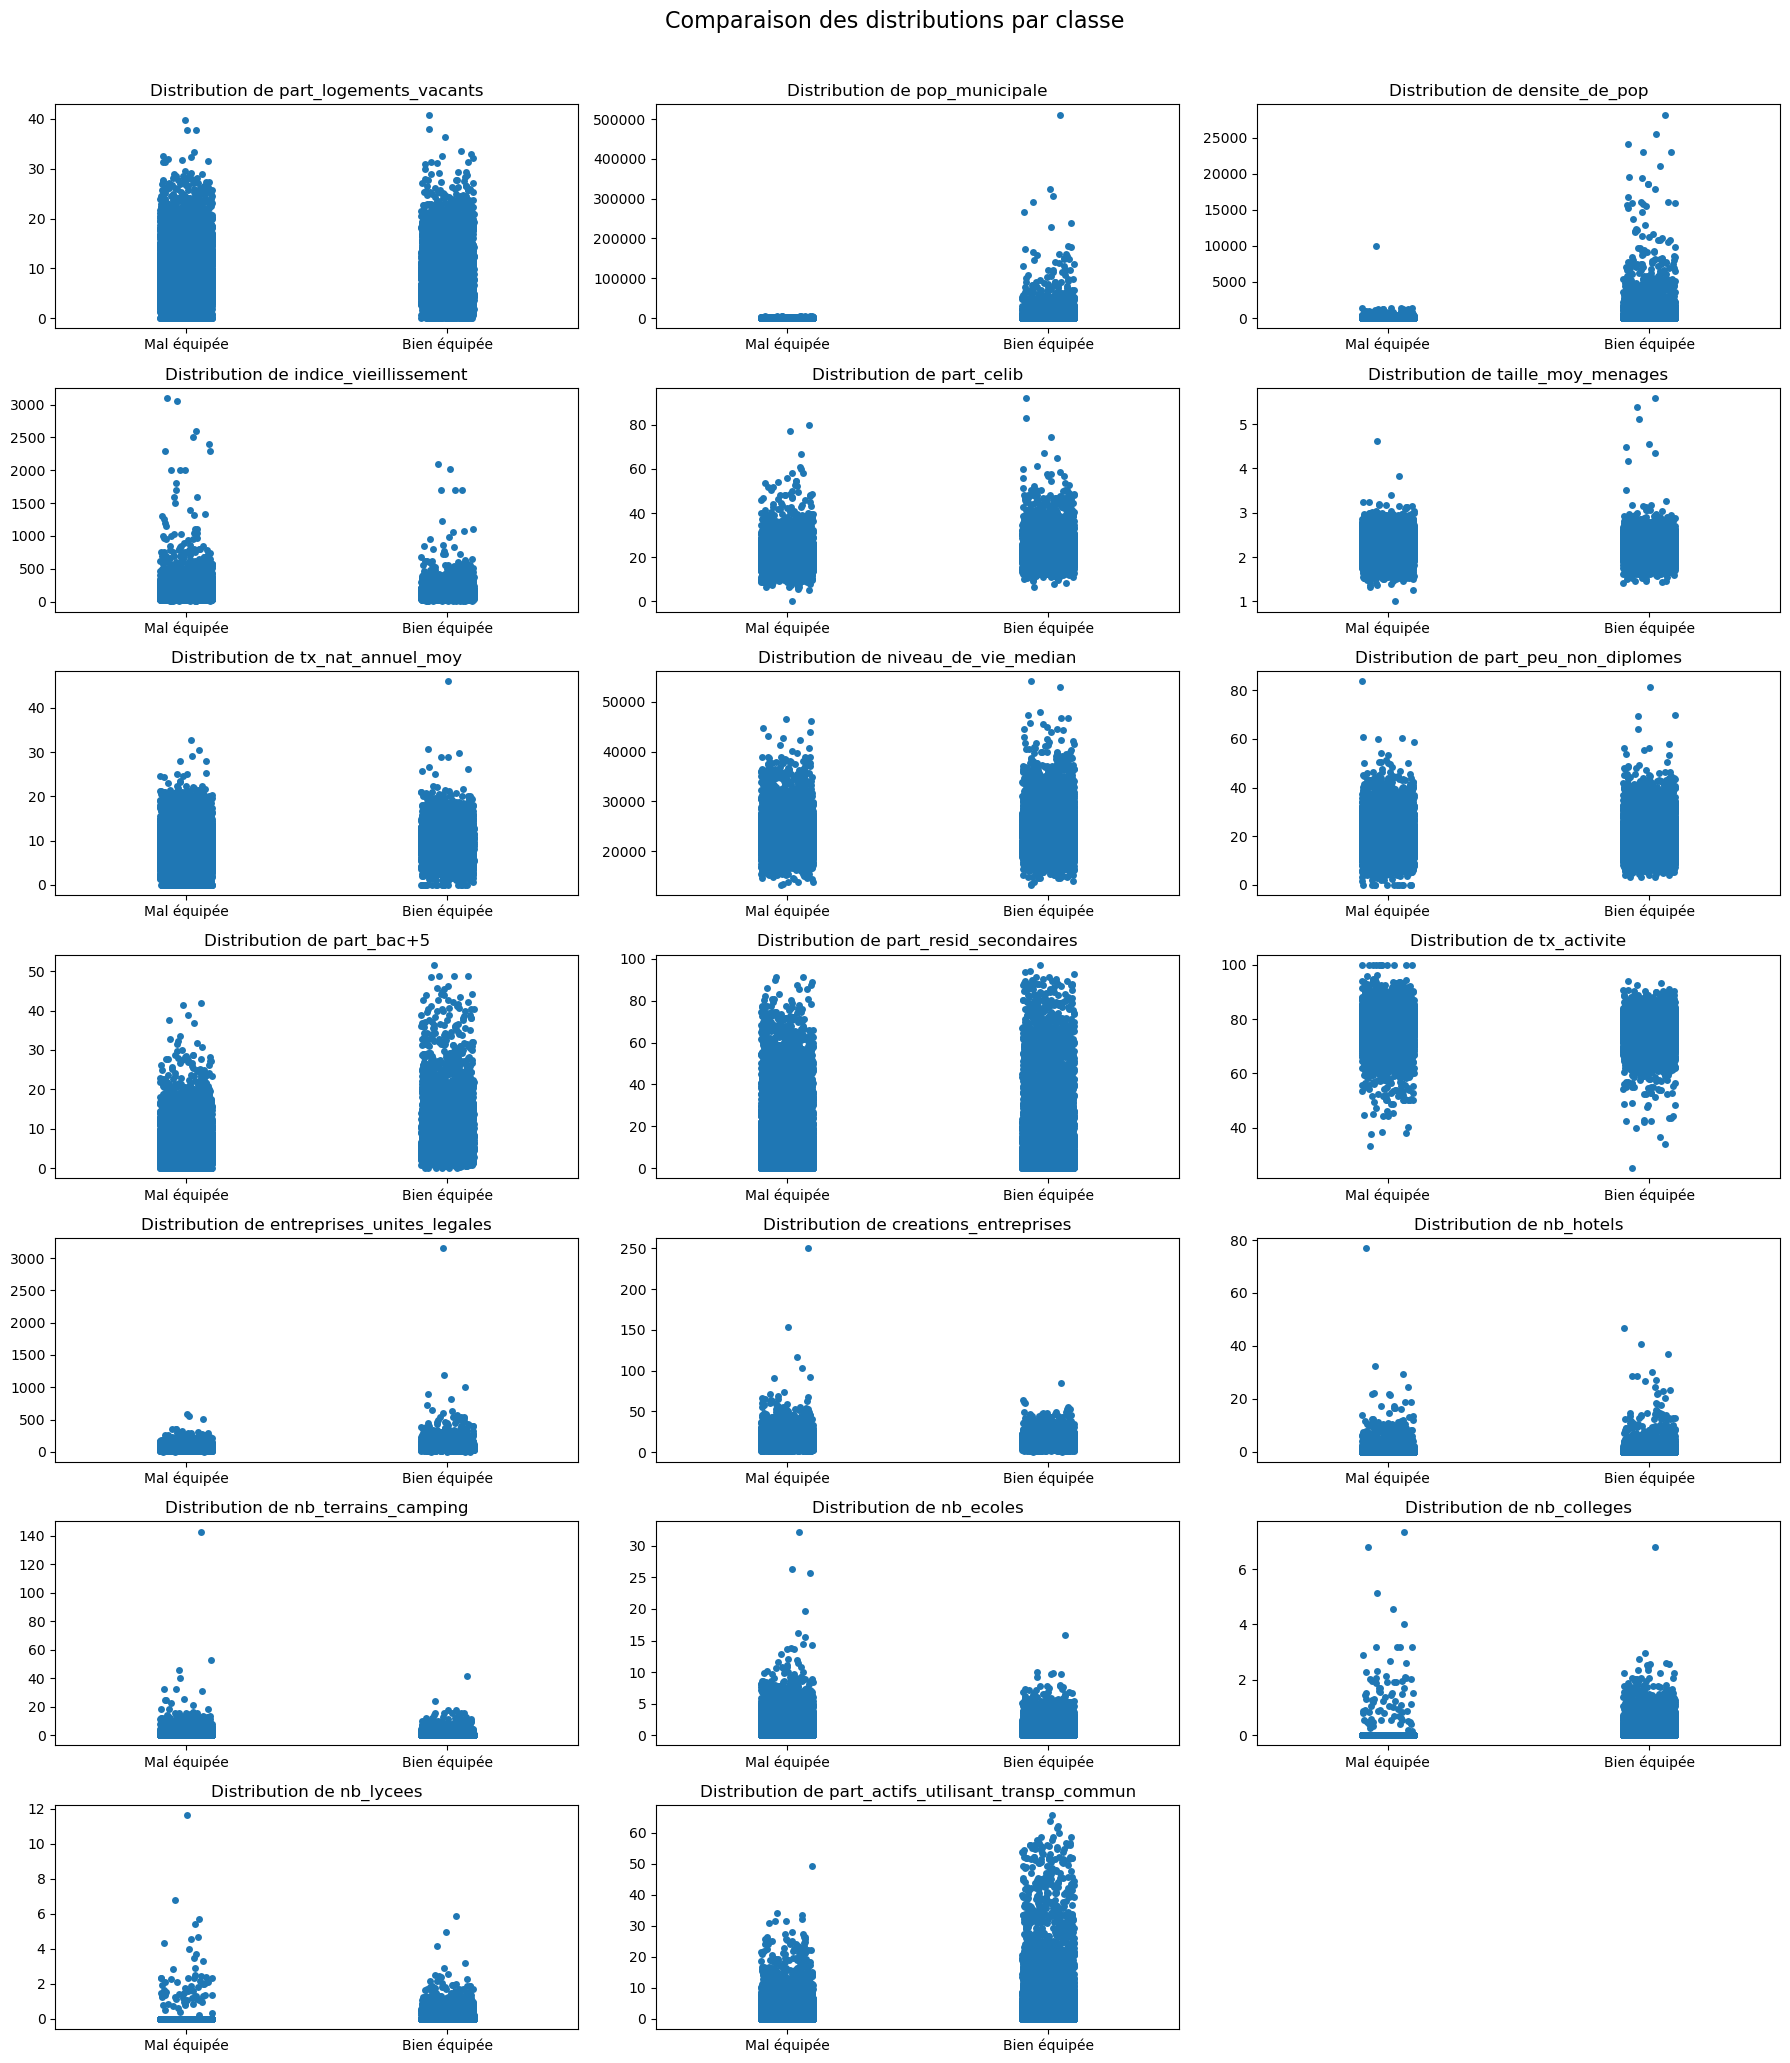

In [37]:
# Comparaison des distributions des variables entre les classes (bien/mal équipée)
# Séparation des données par classe
bien_equipees_insee = df_insee_equipement[df_insee_equipement['bien_equipee'] == 1]
mal_equipees_insee = df_insee_equipement[df_insee_equipement['bien_equipee'] == 0]

# Liste des colonnes numériques à analyser
colonnes_numeriques_insee = df_insee_equipement.columns.drop(['commune', 'bien_equipee', 'code_INSEE'])

plt.figure(figsize=(18, 21))
n_cols = 3
n_rows = (len(colonnes_numeriques_insee) + n_cols - 1) // n_cols

# Création de stripplots comparatifs 
# Remarque : Pas de boxplots ici car certaines variables ici (p. ex. 'nb_lycees') contiennent trop peu d'observations par classe, ce qui ne permet pas de représenter les quartiles
for i, colonne in enumerate(colonnes_numeriques_insee):
    plt.subplot(n_rows, n_cols, i+1)
    
    sns.stripplot(x='bien_equipee', y=colonne, data=df_insee_equipement, jitter=True)

    plt.title(f'Distribution de {colonne}')
    plt.gca().set_xlabel('')
    plt.gca().set_ylabel('')
    plt.xticks([0, 1], ['Mal équipée', 'Bien équipée'])

plt.suptitle('Comparaison des distributions par classe', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [38]:
# Tableau comparatif des statistiques descriptives
stats_comparatives_insee = pd.DataFrame()

for colonne in colonnes_numeriques_insee:
    stats_bien_insee = bien_equipees_insee[colonne].describe()
    stats_mal_insee = mal_equipees_insee[colonne].describe()
    
    # Test de Student pour comparer les moyennes
    t_stat, p_val = stats.ttest_ind(bien_equipees_insee[colonne].dropna(), 
                                   mal_equipees_insee[colonne].dropna(),
                                   equal_var=False)
    
    stats_comp_insee = pd.DataFrame({
        'Variable': [colonne],
        'Moyenne (bien)': [stats_bien_insee['mean']],
        'Moyenne (mal)': [stats_mal_insee['mean']],
        'Médiane (bien)': [stats_bien_insee['50%']],
        'Médiane (mal)': [stats_mal_insee['50%']],
        'Écart-type (bien)': [stats_bien_insee['std']],
        'Écart-type (mal)': [stats_mal_insee['std']],
        'Diff. moyenne (%)': [(stats_bien_insee['mean'] - stats_mal_insee['mean']) / stats_mal_insee['mean'] * 100 if stats_mal_insee['mean'] != 0 else np.nan],
        'p-value': [p_val]
    })
    
    stats_comparatives_insee = pd.concat([stats_comparatives_insee, stats_comp_insee])

stats_comparatives_insee = stats_comparatives_insee.sort_values('Diff. moyenne (%)', ascending=False)
stats_comparatives_insee['Significatif'] = stats_comparatives_insee['p-value'] < 0.05
stats_comparatives_insee = stats_comparatives_insee.reset_index(drop=True)
display(stats_comparatives_insee.style.format({
    'Moyenne (bien)': '{:.2f}',
    'Moyenne (mal)': '{:.2f}',
    'Médiane (bien)': '{:.2f}',
    'Médiane (mal)': '{:.2f}',
    'Écart-type (bien)': '{:.2f}',
    'Écart-type (mal)': '{:.2f}',
    'Diff. moyenne (%)': '{:.1f}%',
    'p-value': '{:.4f}'
}))

,Variable,Moyenne (bien),Moyenne (mal),Médiane (bien),Médiane (mal),Écart-type (bien),Écart-type (mal),Diff. moyenne (%),p-value,Significatif
0,nb_colleges,0.11,0.01,0.00,0.00,0.26,0.16,964.1%,0.0000,True
1,pop_municipale,4273.35,449.22,1556.00,340.00,12742.78,389.98,851.3%,0.0000,True
2,densite_de_pop,367.25,55.29,96.30,33.50,1192.12,115.74,564.3%,0.0000,True
3,nb_lycees,0.05,0.01,0.00,0.00,0.19,0.20,298.7%,0.0000,True
4,part_actifs_utilisant_transp_commun,4.49,2.21,2.20,1.40,7.17,3.00,102.7%,0.0000,True
5,nb_hotels,0.39,0.20,0.00,0.00,1.54,1.35,100.7%,0.0000,True
6,part_bac+5,7.46,5.98,6.00,5.20,5.32,3.80,24.7%,0.0000,True
7,nb_terrains_camping,0.35,0.28,0.00,0.00,1.20,2.00,24.7%,0.0010,True
8,entreprises_unites_legales,75.11,63.39,67.21,58.44,51.48,30.42,18.5%,0.0000,True
9,part_celib,22.37,20.48,21.40,20.00,5.11,4.46,9.3%,0.0000,True


*Remarque :* Quasiment tous les tests de Student sont significatifs, même lorsque les moyennes sont proches (cf. taille d'échantillon très importante).  

De façon intéressante, on remarque que pour certaines variables, la différence de moyennes entre communes bien et mal équipées **contredit nos hypothèses initiales** :   
C'est le cas par exemple pour 'tx_activite', 'nb_ecoles' et 'creations_entreprises' (quoi que pour cette variable, la différence soit non significative) pour lesquelles la moyenne est plus élevée dans les communes mal équipées.  
Idem pour 'taille_moy_menages' et 'part_resid_secondaires' pour qui cela n'était pas attendu, même si on peut l'expliquer plus aisément (des familles nombreuses n'ont pas nécessairement d'argent à allouer à la pratique sportive et des villes avec de nombreuses résidences secondaires peuvent investir moins dans des infrastructures sportives qui seraient peu utilisées à l'année).

#### 3.1.2. Analyse de corrélation
**Objectif :** Déterminer si certaines variables sont redondantes ou inutiles.

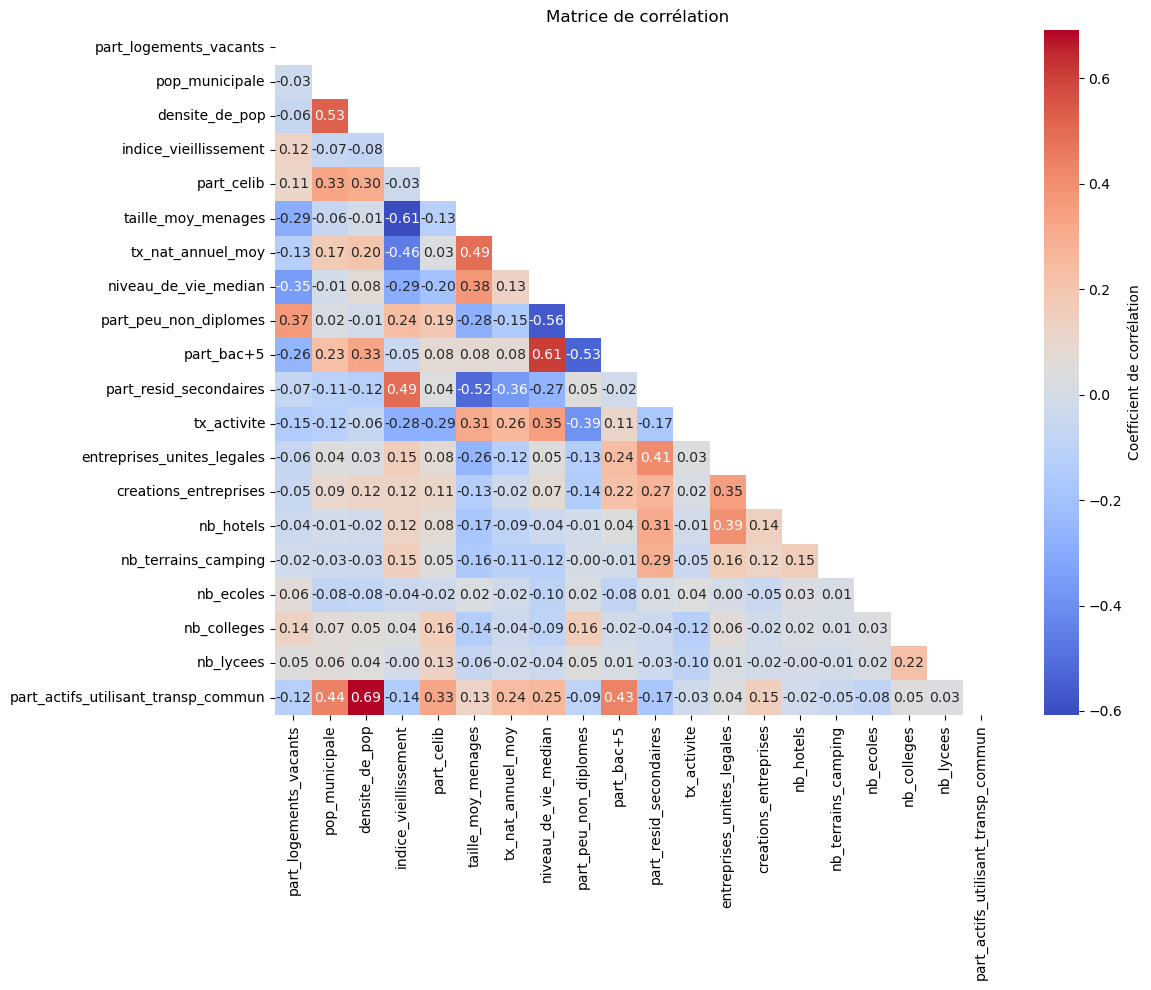

In [39]:
# Matrice de corrélation entre variables explicatives
corr_matrix_insee = df_insee_equipement[list(colonnes_numeriques_insee)].corr()
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix_insee, dtype=bool))
sns.heatmap(corr_matrix_insee, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'label': 'Coefficient de corrélation'})
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

Couples de variables apparaissant comme les plus corrélées : (i) 'densite_de_pop' et 'pop_municipale', (ii) 'part_actifs_utilisant_transp_commun' et 'densite_de_pop', (iii) 'part_bac+5' et 'niveau_de_vie_median'.

- Pour le couple (i), cela est assez logique, mais les deux variables véhiculant tout de même deux informations différentes et particulièrement informatives sur le profil d'une commune, je fais le choix de les conserver ;
- Pour les couples (ii) et (iii), encore une fois ceci s'explique mais les deux informations sont de nature distincte, donc les deux variables sont conservées.
  
*N.B. : Les fortes corrélations ici sont bien moindres par rapport à celles de la partie 1.*

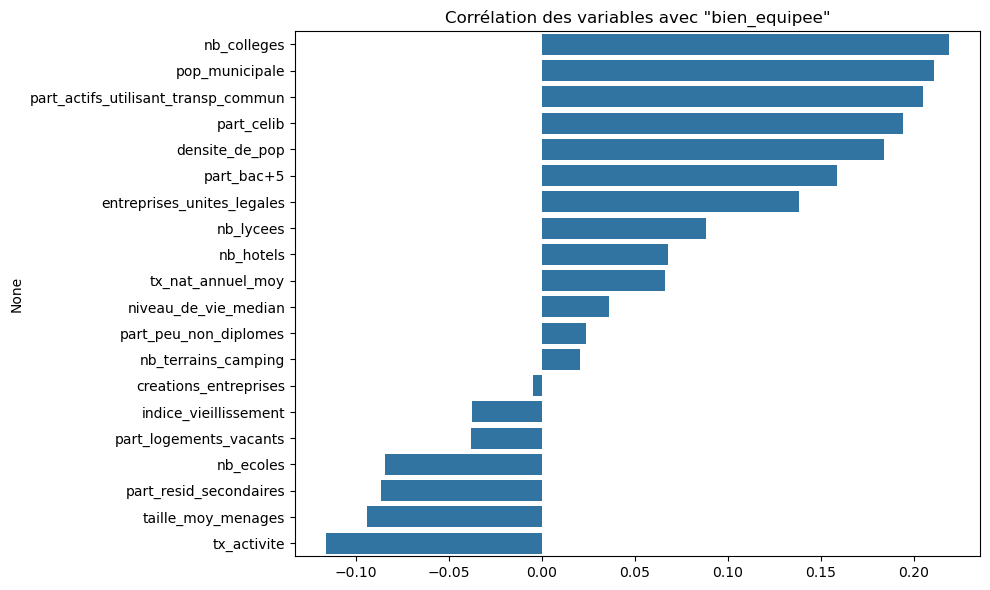

In [40]:
# Graphique en barres montrant la corrélation de chaque variable avec la variable cible 'bien_equipee'
corr_matrix_insee = df_insee_equipement[list(colonnes_numeriques_insee) + ['bien_equipee']].corr()
corr_avec_cible_insee = corr_matrix_insee['bien_equipee'].drop('bien_equipee').sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_avec_cible_insee.values, y=corr_avec_cible_insee.index)
plt.title('Corrélation des variables avec "bien_equipee"')
plt.tight_layout()
plt.show()

Les corrélations linéaires sont faibles, il va être intéressant d'appliquer le modèle de Random Forest pour capturer des relations potentiellement non linéaires (en escalier, en U, en seuil, etc.) ou interactives impliquant ces variables. D'ailleurs, même si une variable n’a pas une forte corrélation linéaire avec la cible, elle peut avoir un pouvoir prédictif important.

### 3.2. Modélisation par Random Forest

In [41]:
# Séparation des variables explicatives et de la variable cible
X_insee = df_insee_equipement.drop(['commune', 'bien_equipee', 'code_INSEE'], axis=1)
y_insee = df_insee_equipement['bien_equipee']

# Normalisation des données
scaler = StandardScaler()
X_scaled_insee = scaler.fit_transform(X_insee)
X_scaled_df_insee = pd.DataFrame(X_scaled_insee, columns=X_insee.columns)

# Séparation en ensembles d'entraînement et de test
# stratify=y pour garantir que la distribution des classes dans la variable cible est préservée dans les deux ensembles
X_train_insee, X_test_insee, y_train_insee, y_test_insee = train_test_split(
    X_scaled_df_insee, y_insee, test_size=0.2, random_state=12, stratify=y_insee
)

# Vérification de l'équilibre des classes 
class_distribution_insee = y_insee.value_counts(normalize=True)
print("Distribution des classes:")
print(class_distribution_insee)

# Si les classes sont déséquilibrées (< 30% pour une classe), on utilise des métriques adaptées
is_imbalanced_insee = min(class_distribution_insee) < 0.3

# Cross-validation initiale avec métriques adaptées
rf_insee = RandomForestClassifier(n_estimators=100, random_state=12)

# Utilisation de métriques appropriées selon l'équilibre des classes
if is_imbalanced_insee:
    scoring_metric_insee = 'f1'  # F1-score est meilleur pour les classes déséquilibrées
else:
    scoring_metric_insee = 'accuracy'  # Accuracy est bien pour les classes équilibrées

print(f"Utilisation de la métrique de scoring: {scoring_metric_insee}")
cv_scores_insee = cross_val_score(rf_insee, X_train_insee, y_train_insee, cv=5, scoring=scoring_metric_insee)
print(f"CV {scoring_metric_insee.capitalize()}: {cv_scores_insee.mean():.4f} ± {cv_scores_insee.std():.4f}")

# Grille de paramètres étendue avec max_features
param_grid_insee = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]  # Ajout de max_features pour gérer les corrélations
}

# Optimisation des hyperparamètres avec RandomizedSearchCV 
rf_random_insee = RandomizedSearchCV(
    rf_insee, 
    param_grid_insee, 
    n_iter=25,  # Augmenté pour explorer plus de combinaisons 
    cv=5, # Chaque combinaison de paramètres est testée sur 5 divisions différentes des données
    random_state=12, 
    n_jobs=-1,
    scoring=scoring_metric_insee
)

rf_random_insee.fit(X_train_insee, y_train_insee)
best_rf_insee = rf_random_insee.best_estimator_ # Modèle Random Forest configuré avec les meilleurs paramètres trouvés

print("Meilleurs paramètres trouvés:")
print(rf_random_insee.best_params_)

# Évaluation complète du meilleur modèle identifié sur l'ensemble test avec métriques multiples
y_pred_insee = best_rf_insee.predict(X_test_insee)
y_prob_insee = best_rf_insee.predict_proba(X_test_insee)[:, 1]  # Probabilités pour la classe positive

# Métriques d'évaluation multiples
print("\n--- Évaluation du modèle ---")
print(f"Accuracy: {accuracy_score(y_test_insee, y_pred_insee):.4f}") 
print(f"Precision: {precision_score(y_test_insee, y_pred_insee):.4f}") 
print(f"Recall: {recall_score(y_test_insee, y_pred_insee):.4f}") 
print(f"F1-Score: {f1_score(y_test_insee, y_pred_insee):.4f}") 
print(f"ROC AUC: {roc_auc_score(y_test_insee, y_prob_insee):.4f}") 

Distribution des classes:
bien_equipee
False    0.51809
True     0.48191
Name: proportion, dtype: float64
Utilisation de la métrique de scoring: accuracy
CV Accuracy: 0.8263 ± 0.0043
Meilleurs paramètres trouvés:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}

--- Évaluation du modèle ---
Accuracy: 0.8317
Precision: 0.8490
Recall: 0.7916
F1-Score: 0.8193
ROC AUC: 0.9043


#### 3.2.1. Interprétation des premières sorties

**Distribution des classes**  
Nos données sont relativement bien équilibrées : 51.81% de communes "mal équipées" et 48.19% de communes "bien équipées".

**Performance du modèle**  
Les résultats du modèle sont très bons.

Accuracy (83.17%) : Le modèle prédit correctement le statut d'équipement de plus de 83% des communes, ce qui est excellent ;
Precision (84.90%) : Parmi les communes que le modèle identifie comme "bien équipées", 84.90% le sont réellement ;
Recall (79.16%) : Le modèle identifie correctement 79.16% des communes qui sont véritablement "bien équipées" ;
F1-Score (81.93%) : Bonne moyenne harmonique entre precision et recall ;
ROC AUC (90.43%) : Score très haut montrant que le modèle distingue très bien les deux classes.

**Meilleurs hyperparamètres**  
Le modèle a retenu un nombre assez élevé d'arbres (n_estimators=200), ce qui lui permet de réduire sa variance et d'augmenter sa robustesse, une profondeur maximale assez importante (max_depth=30), une valeur faible pour min_samples_split=2 et pour min_samples_leaf=2.
L'utilisation de max_features='log2' montre que limiter le nombre de caractéristiques considérées à chaque split est bénéfique. Ce choix favorise la diversité entre les arbres par rapport à 'sqrt'.

**Interprétation générale**  
Notre modèle est très performant pour prédire si une commune est "bien équipée" en se basant sur les 20 variables explicatives que nous avons choisies. Cela suggère que ces variables capturent efficacement les facteurs déterminants pour cette classification, bien qu'elles ne portent par sur les infrastructures sportives en tant que telles. 

#### 3.2.2. Matrice de confusion et importance des variables

In [42]:
# Matrice de confusion 
cm_insee = confusion_matrix(y_test_insee, y_pred_insee)
print("Matrice de confusion :")
print(cm_insee)
# 2210 vrais négatifs, 493 faux négatifs, 333 faux positifs, 1873 vrais positifs

Matrice de confusion :
[[2210  333]
 [ 493 1873]]


In [43]:
print("\nClassification Report:")
print(classification_report(y_test_insee, y_pred_insee))
# Modèle très performant pour les deux classes (bien/mal équipées)


Classification Report:
              precision    recall  f1-score   support

       False       0.82      0.87      0.84      2543
        True       0.85      0.79      0.82      2366

    accuracy                           0.83      4909
   macro avg       0.83      0.83      0.83      4909
weighted avg       0.83      0.83      0.83      4909



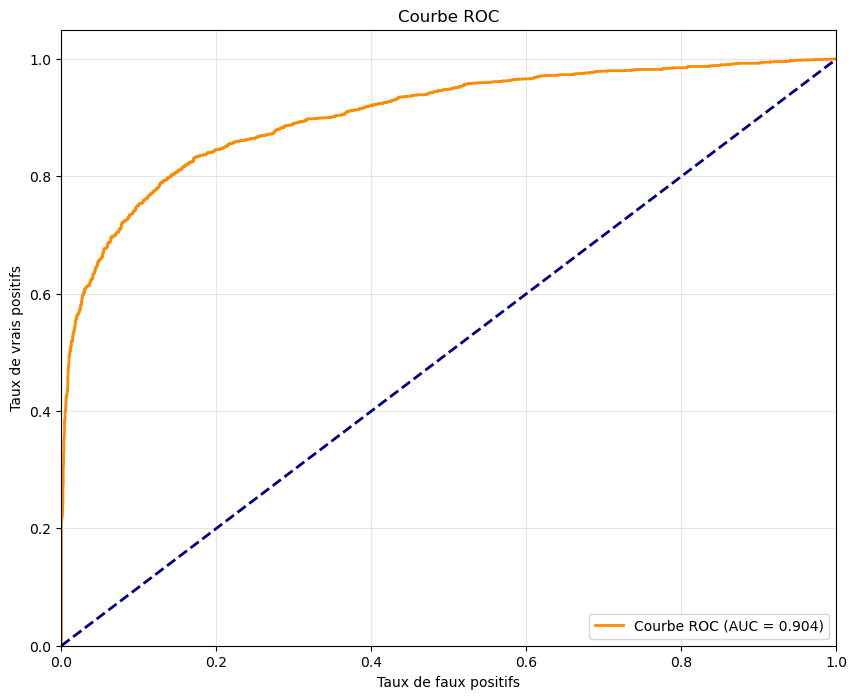

In [44]:
# Visualisation de la courbe ROC
fpr_insee, tpr_insee, thresholds_insee = roc_curve(y_test_insee, y_prob_insee)
roc_auc_insee = auc(fpr_insee, tpr_insee)

plt.figure(figsize=(10, 8))
plt.plot(fpr_insee, tpr_insee, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc_insee:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

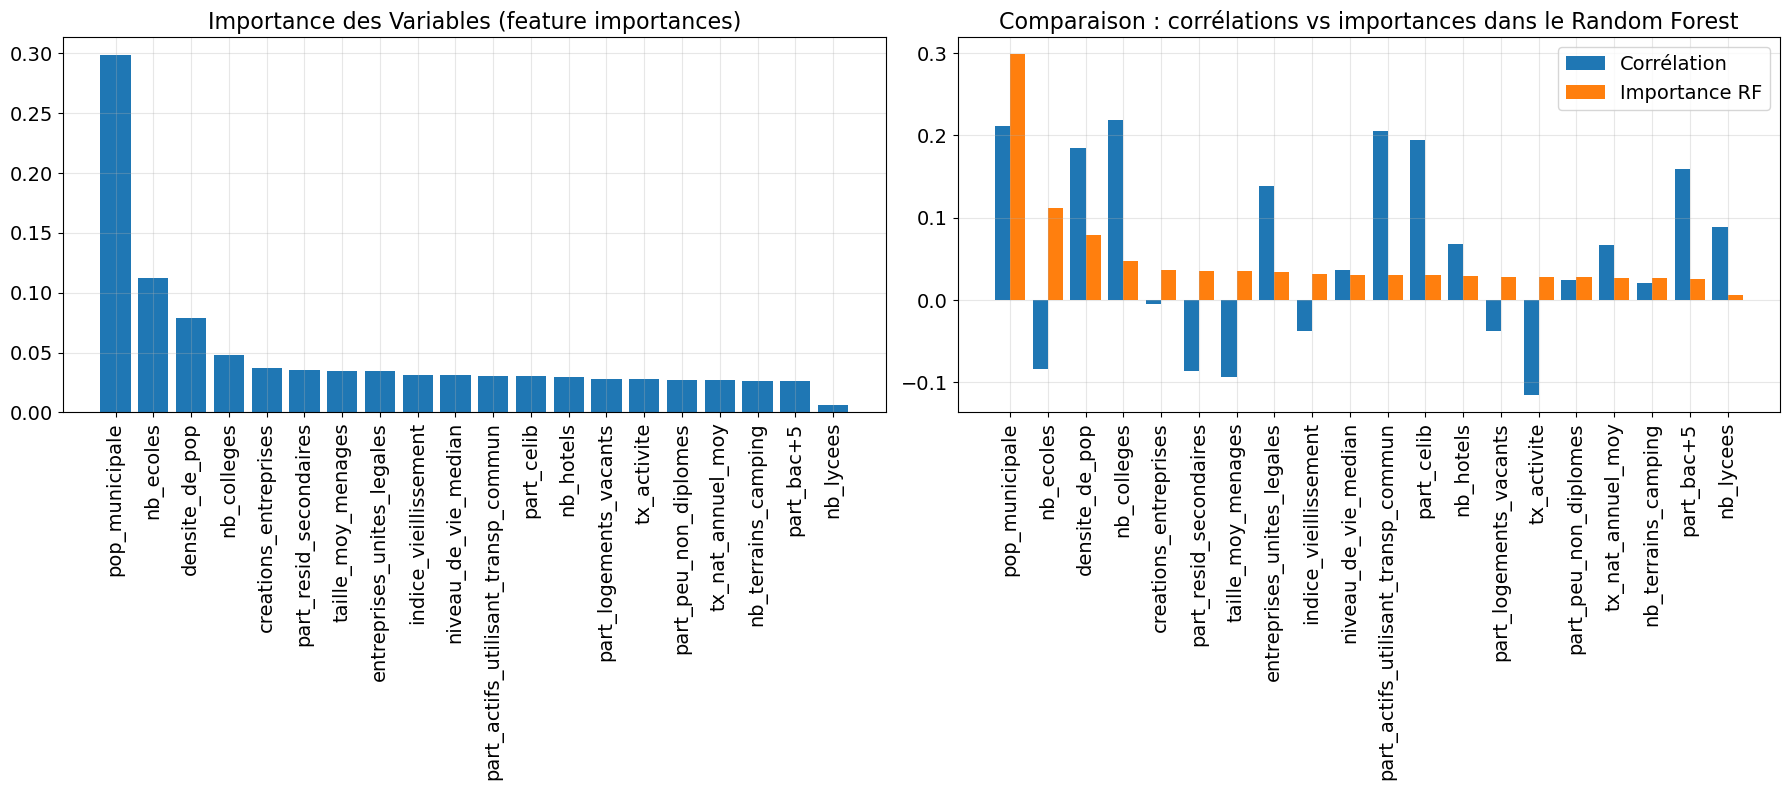

In [45]:
# Première figure : Importance des variables (interprétation avec feature_importances)
importances_insee = best_rf_insee.feature_importances_
indices_insee = np.argsort(importances_insee)[::-1]

# Deuxième figure : Comparaison des importances des variables avec les corrélations initiales
corr_avec_cible_insee = df_insee_equipement[list(X_insee.columns) + ['bien_equipee']].corr()['bien_equipee'].drop('bien_equipee')

# Création du dataframe pour comparer les corrélations et les importances
comparison_df_insee = pd.DataFrame({
    'Variable': X_insee.columns,
    'Correlation': corr_avec_cible_insee,
    'Importance': best_rf_insee.feature_importances_
})
comparison_df_insee = comparison_df_insee.sort_values('Importance', ascending=False)

# Création des subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))  

# Premier plot
axes[0].bar(range(X_train_insee.shape[1]), importances_insee[indices_insee], align='center')
axes[0].set_title('Importance des Variables (feature importances)', fontsize=16)
axes[0].set_xticks(range(X_train_insee.shape[1]))
axes[0].set_xticklabels([X_train_insee.columns[i] for i in indices_insee], rotation=90, fontsize=14)
axes[0].tick_params(axis='y', labelsize=14)
axes[0].grid(True, alpha=0.3)

# Deuxième plot
width = 0.4
idx = np.arange(len(comparison_df_insee))
axes[1].bar(idx - width/2, comparison_df_insee['Correlation'], width, label='Corrélation')
axes[1].bar(idx + width/2, comparison_df_insee['Importance'], width, label='Importance RF')
axes[1].set_xticks(idx)
axes[1].set_xticklabels(comparison_df_insee['Variable'], rotation=90, fontsize=14)
axes[1].tick_params(axis='y', labelsize=14)
axes[1].legend(fontsize=14)
axes[1].set_title('Comparaison : corrélations vs importances dans le Random Forest', fontsize=16)
axes[1].grid(True, alpha=0.3)

# Ajustement des layouts
plt.tight_layout()
plt.show()

Sans surprise, le **nombre d'habitants** de la commune a une très forte importance sur son équipement sportif. Et ce davantage encore que la densité de population, alors qu'on aurait pu imaginer que ce soit le fait d'atteindre une certaine masse critique qui justifie la nécessité de certains équipements.  
Il est très intéressant d'observer des différences significatives entre les corrélations linéaires des variables avec la cible et les importances calculées par Random Forest : **cela indique que le modèle a capturé des relations non linéaires ou des interactions complexes entre les variables**.  
- Une variable avec faible corrélation mais forte importance RF a probablement un effet non linéaire significatif ou participe à des interactions importantes.  
C'est très intéressant concernant le **nombre d'écoles**, qui dans le Random Forest devient très influent : cela veut dire que l'hypothèse de départ est correcte (pression sur l'équipement sportif par les écoles pour leur usage), mais la corrélation n'est pas linéaire comme nous pouvions l'imaginer. 
- Une variable avec forte corrélation mais faible importance RF apporte peut-être une information redondante avec d'autres variables déjà présentes dans le modèle.  
C'est ce que l'on peut imaginer pour 'densite_de_pop' par exemple, très corrélée à 'pop_municipale' et 'part_actifs_utilisant_transp_communs', cf. analyse des corrélations précédente.

In [46]:
# SHAP pour une interprétation plus fine
# explainer = shap.TreeExplainer(best_rf_insee)
# shap_values_insee = explainer(X_test_insee)

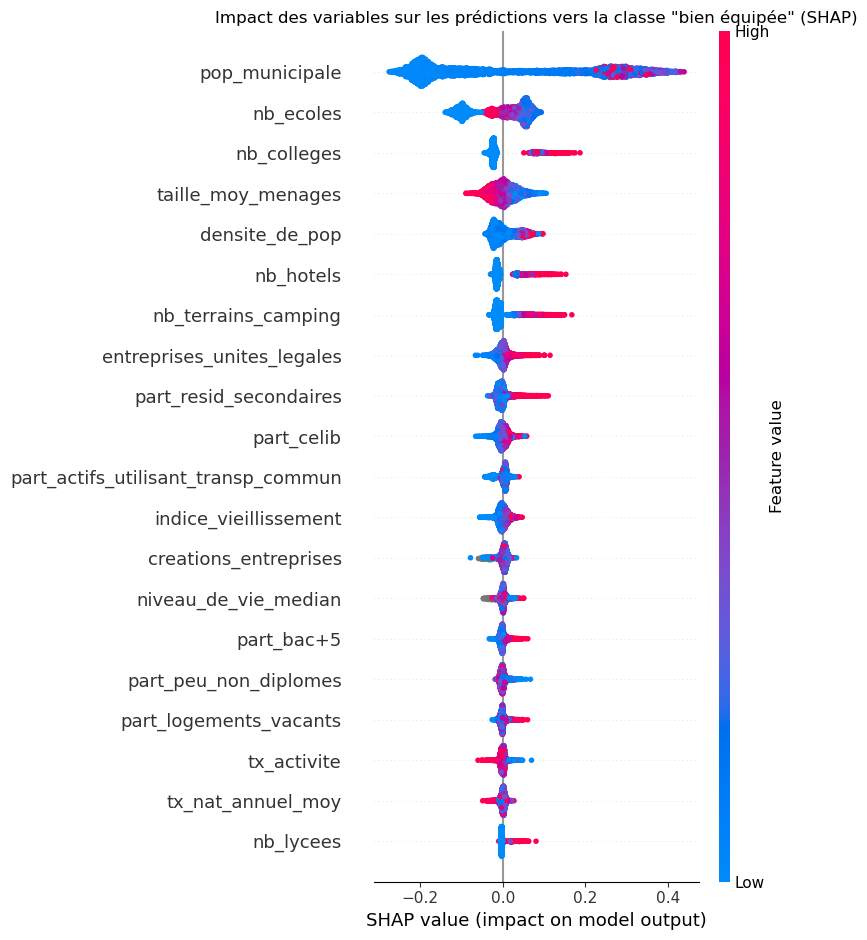

In [47]:
# SHAP values détaillées
# plt.figure(figsize=(12, 10))
# shap.plots.beeswarm(shap_values_insee[:,:,1], show=False, max_display=20) 
# plt.title('Impact des variables sur les prédictions vers la classe "bien équipée" (SHAP)')
# plt.tight_layout()
# plt.show()

## 4. Commentaire final sur la partie 2 : quelle est la portée de ces résultats ?

**Confirmation d'une relation structurelle**  
Ces résultats confirment qu'il existe bien une relation structurelle forte entre les caractéristiques socio-territoriales d'une commune et son niveau d'équipement sportif. Dit autrement, la haute performance prédictive du modèle indique que la répartition des infrastructures sportives n'est pas aléatoire mais suit des logiques territoriales et socio-économiques identifiables. Cela va au-delà d'une simple corrélation linéaire et suggère des dynamiques complexes et multifactorielles qui influencent l'infrastructure sportive.

**Implications pour l'aménagement territorial**  
Ce constat peut avoir des implications importantes pour :
- L'**équité territoriale** : est-ce que certains profils de communes sont systématiquement désavantagés ? Celles avec peu d'habitants ou peu d'établissements scolaires par exemple.  
- Mais aussi, la **planification publique** : identification des communes qui "devraient" être mieux équipées selon leur profil. Celles avec beaucoup d'élèves justement.
  
**Ce modèle peut donc constituer un outil d'aide à la décision pour les politiques publiques d'équipement sportif.**

**Pertinence des variables sélectionnées**  
Les variables démographiques (population, densité, vieillissement) déterminent directement la demande potentielle d'infrastructures sportives.  
A travers les variables socio-économiques (niveau de vie, diplomation), la relation positive entre niveau d'éducation et pratique sportive semble par ailleurs confirmée.  
En outre, les variables d'attractivité territoriale (résidences secondaires, tourisme) captent bien la dynamique spécifique des territoires touristiques qui peuvent avoir des logiques d'équipement particulières.  
Enfin, la prise en compte des variables éducatives (écoles, collèges, lycées) semble importante.

In [48]:
# Saisissez votre commune !
df_insee_equipement[df_insee_equipement['commune'] == 'Saintes']

,code_INSEE,commune,part_logements_vacants,pop_municipale,densite_de_pop,indice_vieillissement,part_celib,taille_moy_menages,tx_nat_annuel_moy,niveau_de_vie_median,...,tx_activite,entreprises_unites_legales,creations_entreprises,nb_hotels,nb_terrains_camping,nb_ecoles,nb_colleges,nb_lycees,part_actifs_utilisant_transp_commun,bien_equipee
2272,17415,Saintes,8.8,25312,560.2,160.7,29.7,1.74,8.0,21770,...,73.1,100.703224,13.234829,0.711125,0.039507,0.750632,0.158028,0.316056,5.5,True
